# Trabajo Práctico Integrador – Machine Learning Aplicado a Datos Reales
## Caso 3 – Enfermedad Renal Crónica (Chronic Kidney Disease, UCI ID 336)

**Estudiante:** Bethania Arami Avila Dominguez
**Taller:** Machine Learning – Proyecto II ML
**Tipo de problema:** clasificación binaria supervisada (`ckd` vs. `notckd`)
**Desafío del caso:** variables numéricas y categóricas con presencia de valores faltantes.
**Pregunta particular:** *¿Cómo afecta el tratamiento de los valores faltantes al desempeño final de los modelos?*

---

### Índice
0. Configuración del entorno y reproducibilidad
1. Descripción y contextualización del problema (§5.1)
2. Descripción del conjunto de datos (§5.2)
3. Análisis exploratorio de datos (§5.3)
4. Preprocesamiento de los datos (§6)
5. Protocolo experimental (§7)
6. Modelos de Machine Learning (§8) y ajuste de hiperparámetros (§9)
7. Evaluación de los modelos sobre Test (§10)
8. Comparación de los modelos (§11)
9. Pregunta particular: efecto del tratamiento de los valores faltantes
10. Discusión de resultados (§12)
11. Conclusiones (§13)
12. Referencias bibliográficas (§14)

> El notebook está pensado para ejecutarse de principio a fin (*Entorno de ejecución → Ejecutar todas*). Tiempo aproximado en Google Colab (CPU): 12–16 minutos (la mayor parte corresponde a la red neuronal en la validación cruzada).

## 0. Configuración del entorno y reproducibilidad

Se instalan/importan las bibliotecas y se fija una **semilla global** (`SEED = 42`) para NumPy, Python y TensorFlow, de modo que la partición de datos, la validación cruzada y el entrenamiento de la red neuronal sean reproducibles.

In [1]:
# Instalación de la biblioteca oficial de acceso al UCI ML Repository (en Colab)
import sys, subprocess
try:
    import ucimlrepo  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ucimlrepo"], check=False)

In [2]:
import os, random, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RepeatedStratifiedKFold, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
PALETA = {"ckd": "#C0392B", "notckd": "#2E86C1"}

def guardar(fig, nombre):
    fig.savefig(FIG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")

print("Python     :", sys.version.split()[0])
import sklearn
print("scikit-learn:", sklearn.__version__)
print("pandas      :", pd.__version__)
print("TensorFlow  :", tf.__version__)

I0000 00:00:1790219883.433093   30065 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790219885.666563   30065 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python     : 3.11.15
scikit-learn: 1.9.1
pandas      : 3.0.6
TensorFlow  : 2.21.0


## 1. Descripción y contextualización del problema (§5.1)

**¿Cuál es el problema?** La **enfermedad renal crónica (ERC / CKD)** es la pérdida progresiva e irreversible de la función renal durante más de tres meses [2]. En sus etapas iniciales suele ser **asintomática**, por lo que muchos pacientes se diagnostican tarde, cuando ya requieren diálisis o trasplante. La ERC afecta a cerca del 9 % de la población mundial y es una causa creciente de mortalidad [3].

**Contexto de aplicación.** Tamizaje (*screening*) clínico en atención primaria u hospitalaria: a partir de análisis de sangre y orina rutinarios (hemoglobina, creatinina sérica, urea, gravedad específica y albúmina en orina, etc.) y antecedentes (hipertensión, diabetes), se busca identificar pacientes con ERC. Los datos provienen del Apollo Hospitals (Tamil Nadu, India) [1].

**¿Por qué Machine Learning?** El diagnóstico combina muchas variables heterogéneas (numéricas y categóricas) con datos incompletos. Un modelo de ML puede aprender la combinación de marcadores que mejor separa a los pacientes y servir como **herramienta de apoyo** para priorizar estudios confirmatorios (no reemplaza al nefrólogo). Trabajos previos sobre este mismo dataset reportan desempeños muy altos [4], [5].

**¿Qué se desea predecir?** Si un paciente **tiene o no ERC**.

| Clase | Significado | Codificación |
|---|---|---|
| `ckd` | Paciente con enfermedad renal crónica | **1 (clase positiva)** |
| `notckd` | Paciente sin enfermedad renal crónica | 0 |

**Variable objetivo:** `class`. Se toma `ckd` como clase positiva porque el error más costoso en tamizaje es el **falso negativo** (un enfermo no detectado); por eso, además de Accuracy, se prestará especial atención al **Recall (sensibilidad)** y al **F1-score**.

## 2. Descripción del conjunto de datos (§5.2)

### 2.1 Carga de los datos

Siguiendo el Anexo A, los datos se cargan desde el **UCI Machine Learning Repository** con `ucimlrepo` (`fetch_ucirepo(id=336)`). Como respaldo (por ejemplo, si UCI no está disponible), el notebook lee el archivo original `chronic_kidney_disease_full.arff` descargado de la misma página de UCI (Opción A del Anexo). En Colab puede subirse a la carpeta `data/` o a la raíz del entorno.

El archivo ARFF original tiene algunas filas mal formadas (comas sobrantes), por lo que se usa un lector propio y tolerante.

In [3]:
NUM_COLS = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc", "sod", "pot",
            "hemo", "pcv", "wbcc", "rbcc"]
CAT_COLS = ["rbc", "pc", "pcc", "ba", "htn", "dm", "cad", "appet", "pe", "ane"]
TARGET = "class"

def leer_arff_ckd(ruta):
    # Lee el ARFF de UCI tolerando las filas con comas sobrantes del archivo original.
    atributos, filas, en_datos, corregidas = [], [], False, 0
    with open(ruta, encoding="latin-1") as f:
        for linea in f:
            linea = linea.strip()
            if not linea or linea.startswith("%"):
                continue
            if linea.lower().startswith("@attribute"):
                atributos.append(linea.split()[1].strip("'"))
            elif linea.lower().startswith("@data"):
                en_datos = True
            elif en_datos:
                valores = [v.strip() for v in linea.split(",")]
                if len(valores) != len(atributos):
                    valores = [v for v in valores if v != ""]   # quita campos vacíos sobrantes
                    corregidas += 1
                if len(valores) == len(atributos):
                    filas.append(valores)
    df = pd.DataFrame(filas, columns=atributos)
    print(f"ARFF leído: {df.shape[0]} filas; filas con comas sobrantes corregidas: {corregidas}")
    return df

def cargar_datos():
    try:
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=336)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Fuente: UCI ML Repository vía ucimlrepo (id=336)")
        return df, ds
    except Exception as e:
        print(f"No se pudo usar ucimlrepo ({type(e).__name__}: {str(e)[:90]}). Se usa el ARFF local.")
    for ruta in ["data/chronic_kidney_disease_full.arff", "chronic_kidney_disease_full.arff",
                 "../data/chronic_kidney_disease_full.arff"]:
        if Path(ruta).exists():
            print("Fuente: archivo local", ruta, "(descargado de UCI, dataset 336)")
            return leer_arff_ckd(ruta), None
    raise FileNotFoundError("Suba 'chronic_kidney_disease_full.arff' a la carpeta data/ del entorno.")

df_raw, ds_uci = cargar_datos()
print("Dimensiones originales:", df_raw.shape)
df_raw.head()

No se pudo usar ucimlrepo (ConnectionError: Error connecting to server). Se usa el ARFF local.
Fuente: archivo local data/chronic_kidney_disease_full.arff (descargado de UCI, dataset 336)
ARFF leído: 400 filas; filas con comas sobrantes corregidas: 3
Dimensiones originales: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,?,normal,notpresent,notpresent,121,36,1.2,?,?,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,?,normal,notpresent,notpresent,?,18,0.8,?,?,11.3,38,6000,?,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,53,1.8,?,?,9.6,31,7500,?,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,26,1.4,?,?,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [4]:
# Metadatos oficiales de UCI (solo disponibles si la carga se hizo con ucimlrepo)
if ds_uci is not None:
    print(ds_uci.metadata.get("name"), "|", ds_uci.metadata.get("repository_url"))
    display(ds_uci.variables[["name", "role", "type", "description", "units", "missing_values"]])

### 2.2 Limpieza de formato

Antes de describir los datos se normaliza el formato (esto **no** es preprocesamiento aprendido, solo corrección de errores de tipeo, por lo que no genera *data leakage*):
- se eliminan espacios y tabulaciones sobrantes en los valores de texto (en la fuente aparecen valores como `"\tno"`, `" yes"` o `"ckd\t"`);
- `?` y cadenas vacías se convierten en `NaN` (valor faltante);
- las variables numéricas se convierten a tipo numérico.

In [5]:
def limpiar_formato(df):
    df = df.copy()
    df.columns = [str(c).strip().strip("'").lower() for c in df.columns]
    df = df.rename(columns={"wc": "wbcc", "rc": "rbcc"})
    sucios = 0
    for c in df.columns:
        if not pd.api.types.is_numeric_dtype(df[c]):
            s = df[c].astype("string")
            sucios += int((s.notna() & (s != s.str.strip())).sum())
            s = s.str.replace("\t", "", regex=False).str.strip()
            df[c] = s.replace({"?": pd.NA, "": pd.NA, "nan": pd.NA}).astype(object)
            df[c] = df[c].where(df[c].notna(), np.nan)
    for c in NUM_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float)
    print(f"Valores de texto con espacios/tabulaciones corregidos: {sucios}")
    return df[NUM_COLS + CAT_COLS + [TARGET]]

df = limpiar_formato(df_raw)
print("Valores de la clase:", df[TARGET].value_counts(dropna=False).to_dict())
for c in CAT_COLS:
    assert set(df[c].dropna().unique()) <= {"normal", "abnormal", "present", "notpresent",
                                             "yes", "no", "good", "poor"}, c
print("Filas duplicadas:", df.duplicated().sum())
df.info()

Valores de texto con espacios/tabulaciones corregidos: 0
Valores de la clase: {'ckd': 250, 'notckd': 150}
Filas duplicadas: 0
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   bgr     356 non-null    float64
 6   bu      381 non-null    float64
 7   sc      383 non-null    float64
 8   sod     313 non-null    float64
 9   pot     312 non-null    float64
 10  hemo    348 non-null    float64
 11  pcv     329 non-null    float64
 12  wbcc    294 non-null    float64
 13  rbcc    269 non-null    float64
 14  rbc     248 non-null    object 
 15  pc      335 non-null    object 
 16  pcc     396 non-null    object 
 17  ba      396 non-null    object 
 18  htn     398 non-null    object 
 19

### 2.3 Ficha técnica del dataset

In [6]:
DESCRIPCION = {
    "age": ("Edad", "años"), "bp": ("Presión arterial (diastólica)", "mm/Hg"),
    "sg": ("Gravedad específica de la orina", "ordinal (1.005–1.025)"),
    "al": ("Albúmina en orina", "ordinal (0–5)"), "su": ("Azúcar en orina", "ordinal (0–5)"),
    "bgr": ("Glucosa en sangre (aleatoria)", "mg/dl"), "bu": ("Urea en sangre", "mg/dl"),
    "sc": ("Creatinina sérica", "mg/dl"), "sod": ("Sodio", "mEq/L"), "pot": ("Potasio", "mEq/L"),
    "hemo": ("Hemoglobina", "g/dl"), "pcv": ("Volumen celular empaquetado (hematocrito)", "%"),
    "wbcc": ("Recuento de glóbulos blancos", "células/mm³"),
    "rbcc": ("Recuento de glóbulos rojos", "millones/mm³"),
    "rbc": ("Glóbulos rojos en orina", "normal / abnormal"), "pc": ("Células de pus", "normal / abnormal"),
    "pcc": ("Grumos de células de pus", "present / notpresent"), "ba": ("Bacterias", "present / notpresent"),
    "htn": ("Hipertensión", "yes / no"), "dm": ("Diabetes mellitus", "yes / no"),
    "cad": ("Enfermedad coronaria", "yes / no"), "appet": ("Apetito", "good / poor"),
    "pe": ("Edema pedal", "yes / no"), "ane": ("Anemia", "yes / no"),
}
ficha = pd.DataFrame({
    "Variable": list(DESCRIPCION),
    "Descripción": [v[0] for v in DESCRIPCION.values()],
    "Unidad / valores": [v[1] for v in DESCRIPCION.values()],
    "Tipo": ["Numérica (ordinal)" if c in ["sg", "al", "su"] else
             ("Numérica" if c in NUM_COLS else "Categórica binaria") for c in DESCRIPCION],
    "% faltantes": [round(df[c].isna().mean() * 100, 1) for c in DESCRIPCION],
})
resumen = pd.Series({
    "Nombre": "Chronic Kidney Disease (Early stage of Indians CKD)",
    "Fuente": "UCI Machine Learning Repository, ID 336 (Rubini, Soundarapandian y Eswaran, 2015)",
    "Instancias": df.shape[0],
    "Atributos predictores": len(NUM_COLS) + len(CAT_COLS),
    "Variable objetivo": "class (ckd / notckd)",
    "Número de clases": df[TARGET].nunique(),
    "Numéricas / categóricas": f"{len(NUM_COLS)} numéricas (11 continuas + 3 ordinales) / {len(CAT_COLS)} binarias",
    "Distribución de clases": df[TARGET].value_counts().to_dict(),
    "Celdas faltantes": f"{df.isna().sum().sum()} ({df[NUM_COLS + CAT_COLS].isna().mean().mean():.1%} del total)",
    "Filas completas (sin faltantes)": int(df.dropna().shape[0]),
}, name="Valor")
display(resumen.to_frame())
display(ficha)

,Valor
Nombre,Chronic Kidney Disease (Early stage of Indians...
Fuente,"UCI Machine Learning Repository, ID 336 (Rubin..."
Instancias,400
Atributos predictores,24
Variable objetivo,class (ckd / notckd)
Número de clases,2
Numéricas / categóricas,14 numéricas (11 continuas + 3 ordinales) / 10...
Distribución de clases,"{'ckd': 250, 'notckd': 150}"
Celdas faltantes,1012 (10.5% del total)
Filas completas (sin faltantes),158


,Variable,Descripción,Unidad / valores,Tipo,% faltantes
0,age,Edad,años,Numérica,2.2
1,bp,Presión arterial (diastólica),mm/Hg,Numérica,3.0
2,sg,Gravedad específica de la orina,ordinal (1.005–1.025),Numérica (ordinal),11.8
3,al,Albúmina en orina,ordinal (0–5),Numérica (ordinal),11.5
4,su,Azúcar en orina,ordinal (0–5),Numérica (ordinal),12.2
5,bgr,Glucosa en sangre (aleatoria),mg/dl,Numérica,11.0
6,bu,Urea en sangre,mg/dl,Numérica,4.8
7,sc,Creatinina sérica,mg/dl,Numérica,4.2
8,sod,Sodio,mEq/L,Numérica,21.8
9,pot,Potasio,mEq/L,Numérica,22.0


**Variables predictoras utilizadas.** Se usan las **24 variables** originales: 14 numéricas (incluidas `sg`, `al` y `su`, que en el ARFF figuran como nominales pero tienen un **orden natural**, por lo que se tratan como ordinales numéricas) y 10 categóricas binarias. No se elimina ninguna a priori: todas tienen sentido clínico y el número de atributos es bajo en relación con las instancias.

**Datos faltantes.** Sí existen, y en cantidad importante: solo alrededor del 40 % de los pacientes tiene el registro completo. Este es el desafío central del caso y se analiza en detalle en la Sección 9.

## 3. Análisis exploratorio de datos (§5.3)

El EDA se realiza sobre el dataset completo con fines **descriptivos**. Ninguna transformación aprendida de los datos (valores de imputación, medias y desvíos del escalado, columnas eliminadas) se calcula aquí: todas se aprenden más adelante **solo con el conjunto de entrenamiento**, dentro de *pipelines*.

### 3.1 Distribución de clases

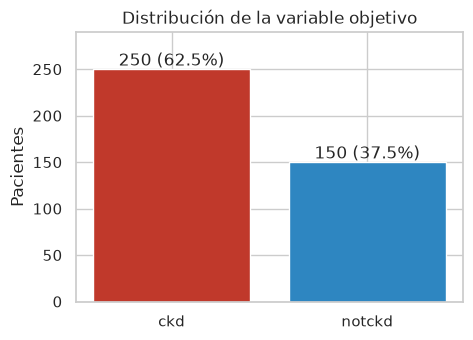

Razón de desbalance ckd:notckd = 1.67 : 1


In [7]:
conteo = df[TARGET].value_counts()
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(conteo.index, conteo.values, color=[PALETA[c] for c in conteo.index])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 4, f"{v} ({v / len(df):.1%})", ha="center")
ax.set_title("Distribución de la variable objetivo"); ax.set_ylabel("Pacientes"); ax.set_ylim(0, 290)
guardar(fig, "01_distribucion_clases"); plt.show()
print(f"Razón de desbalance ckd:notckd = {conteo['ckd'] / conteo['notckd']:.2f} : 1")

**Interpretación.** El dataset tiene 250 pacientes con ERC (62,5 %) y 150 sin ERC (37,5 %). Es un **desbalance moderado** (1,67:1), que no exige técnicas de sobre/submuestreo, pero sí: (i) **estratificar** la partición y la validación cruzada, y (ii) no confiar solo en Accuracy (un clasificador que dijera siempre `ckd` ya obtendría 62,5 %).

### 3.2 Valores faltantes

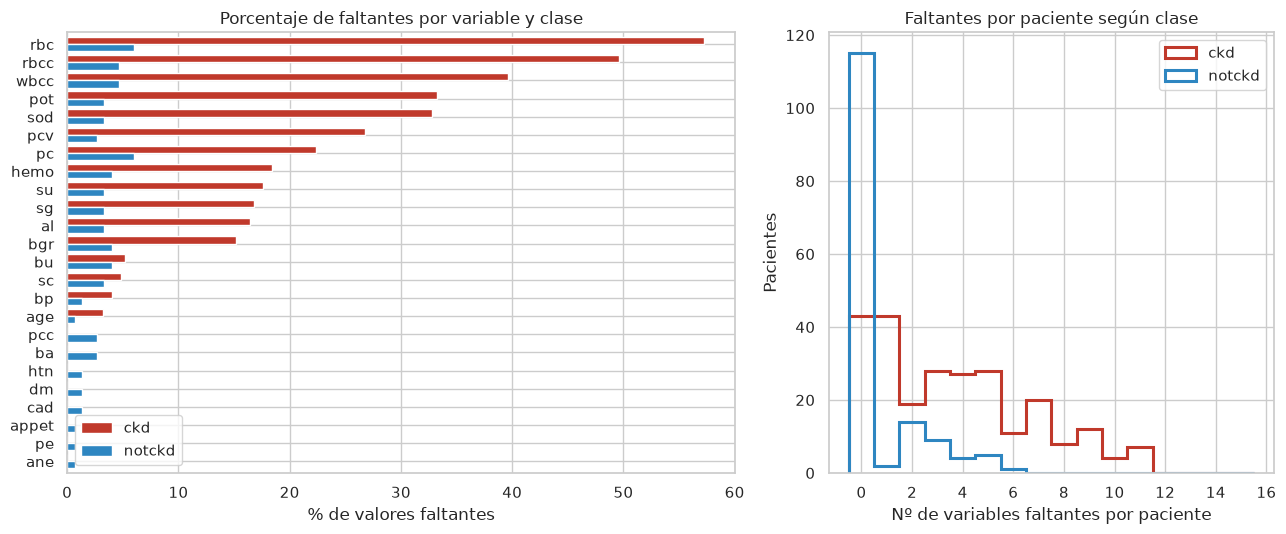

,rbc,rbcc,wbcc,pot,sod,pcv,pc,hemo,su,sg
Global,38.0,32.8,26.5,22.0,21.8,17.8,16.2,13.0,12.2,11.8
ckd,57.2,49.6,39.6,33.2,32.8,26.8,22.4,18.4,17.6,16.8
notckd,6.0,4.7,4.7,3.3,3.3,2.7,6.0,4.0,3.3,3.3


Filas completas: 158 de 400 -> distribución en filas completas: {'notckd': 115, 'ckd': 43}
Media de faltantes por paciente: {'ckd': 3.63, 'notckd': 0.69}


In [8]:
falt = pd.DataFrame({
    "Global": df[NUM_COLS + CAT_COLS].isna().mean() * 100,
    "ckd": df[df[TARGET] == "ckd"][NUM_COLS + CAT_COLS].isna().mean() * 100,
    "notckd": df[df[TARGET] == "notckd"][NUM_COLS + CAT_COLS].isna().mean() * 100,
}).sort_values("Global", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.5, 1]})
falt[["ckd", "notckd"]].plot.barh(ax=axes[0], color=[PALETA["ckd"], PALETA["notckd"]], width=0.8)
axes[0].invert_yaxis(); axes[0].set_xlabel("% de valores faltantes")
axes[0].set_title("Porcentaje de faltantes por variable y clase")

n_falt = df[NUM_COLS + CAT_COLS].isna().sum(axis=1)
for clase in ["ckd", "notckd"]:
    axes[1].hist(n_falt[df[TARGET] == clase], bins=np.arange(-0.5, 16.5, 1), histtype="step",
                 lw=2.2, label=clase, color=PALETA[clase])
axes[1].set_xlabel("Nº de variables faltantes por paciente"); axes[1].set_ylabel("Pacientes")
axes[1].set_title("Faltantes por paciente según clase"); axes[1].legend()
plt.tight_layout(); guardar(fig, "02_faltantes"); plt.show()

display(falt.round(1).head(10).T)
completos = df.dropna()
print(f"Filas completas: {len(completos)} de {len(df)} "
      f"-> distribución en filas completas: {completos[TARGET].value_counts().to_dict()}")
print("Media de faltantes por paciente:", n_falt.groupby(df[TARGET]).mean().round(2).to_dict())

**Interpretación (clave para el caso).**
- Las variables con más faltantes son `rbc` (~38 %), `rbcc` (~33 %), `wbcc` (~26 %), `pot` y `sod` (~22 %) y `pcv` (~18 %).
- Los faltantes **no son aleatorios respecto de la clase**: los pacientes con ERC tienen en promedio muchos más valores faltantes que los pacientes sanos. En términos de Rubin [11], los datos **no son MCAR** (*Missing Completely At Random*); el hecho de que falte una medición está asociado a la clase (probablemente porque el protocolo de registro fue distinto para cada grupo).
- Consecuencia práctica: si se eliminan las filas incompletas, quedan solo 158 pacientes y **la clase `ckd` pasa de mayoritaria (62,5 %) a minoritaria (~27 %)**. Esto sesga fuertemente la muestra y es un primer indicio de que el tratamiento de faltantes puede afectar el desempeño (Sección 9).

### 3.3 Estadísticas descriptivas y distribución de las variables numéricas

In [9]:
desc = df.groupby(TARGET)[NUM_COLS].agg(["median", "mean", "std"]).T.unstack(level=1).round(2)
display(df[NUM_COLS].describe().T.round(2))
display(df.groupby(TARGET)[NUM_COLS].median().T.round(2).rename(columns=lambda c: f"mediana_{c}"))

,count,mean,std,min,25%,50%,75%,max
age,391.0,51.48,17.17,2.0,42.00,55.00,64.50,90.00
bp,388.0,76.47,13.68,50.0,70.00,80.00,80.00,180.00
sg,353.0,1.02,0.01,1.0,1.01,1.02,1.02,1.02
al,354.0,1.02,1.35,0.0,0.00,0.00,2.00,5.00
su,351.0,0.45,1.10,0.0,0.00,0.00,0.00,5.00
bgr,356.0,148.04,79.28,22.0,99.00,121.00,163.00,490.00
bu,381.0,57.43,50.50,1.5,27.00,42.00,66.00,391.00
sc,383.0,3.07,5.74,0.4,0.90,1.30,2.80,76.00
sod,313.0,137.53,10.41,4.5,135.00,138.00,142.00,163.00
pot,312.0,4.63,3.19,2.5,3.80,4.40,4.90,47.00


class,mediana_ckd,mediana_notckd
age,59.00,46.00
bp,80.00,70.00
sg,1.01,1.02
al,2.00,0.00
su,0.00,0.00
bgr,143.50,107.50
bu,53.00,33.00
sc,2.25,0.90
sod,136.00,141.00
pot,4.30,4.50


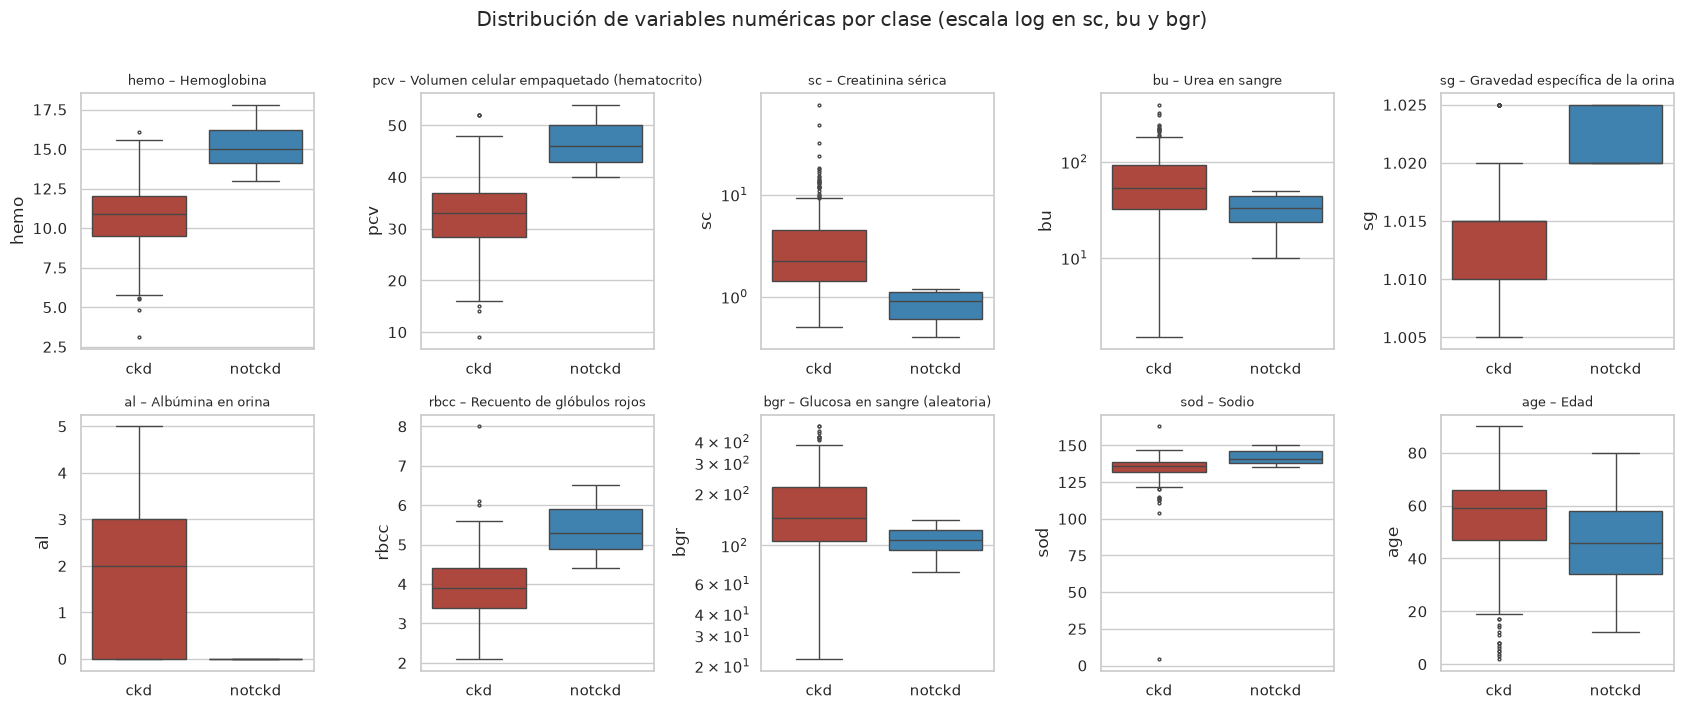

In [10]:
vars_plot = ["hemo", "pcv", "sc", "bu", "sg", "al", "rbcc", "bgr", "sod", "age"]
fig, axes = plt.subplots(2, 5, figsize=(17, 7))
for ax, v in zip(axes.ravel(), vars_plot):
    sns.boxplot(data=df, x=TARGET, y=v, hue=TARGET, palette=PALETA, ax=ax, order=["ckd", "notckd"],
                legend=False, fliersize=2)
    ax.set_title(f"{v} – {DESCRIPCION[v][0]}", fontsize=9); ax.set_xlabel("")
    if v in ["sc", "bu", "bgr"]:
        ax.set_yscale("log")
fig.suptitle("Distribución de variables numéricas por clase (escala log en sc, bu y bgr)", y=1.01)
plt.tight_layout(); guardar(fig, "03_boxplots"); plt.show()

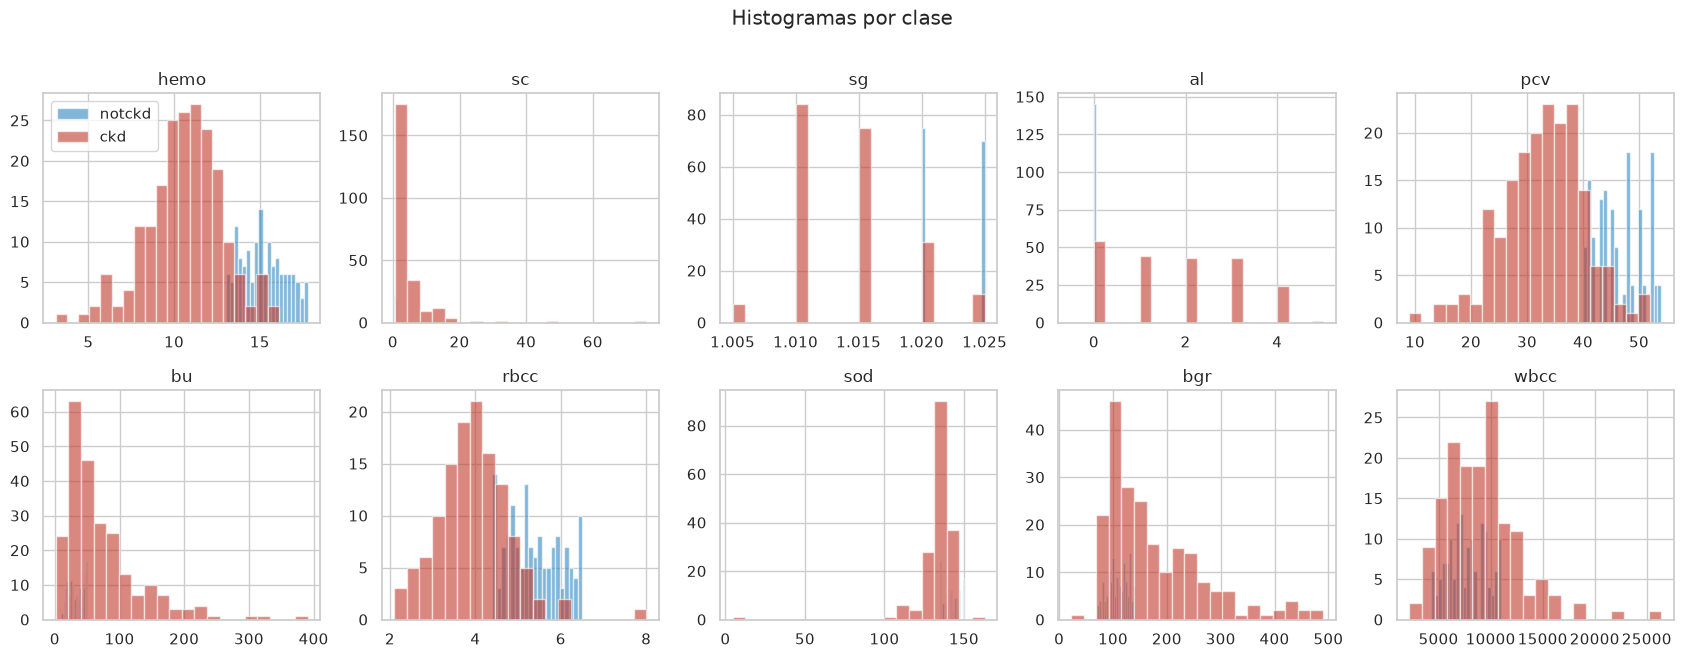

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(17, 6.5))
for ax, v in zip(axes.ravel(), ["hemo", "sc", "sg", "al", "pcv", "bu", "rbcc", "sod", "bgr", "wbcc"]):
    for clase in ["notckd", "ckd"]:
        datos = df.loc[df[TARGET] == clase, v].dropna()
        ax.hist(datos, bins=20, alpha=0.6, color=PALETA[clase], label=clase)
    ax.set_title(v)
axes[0, 0].legend()
fig.suptitle("Histogramas por clase", y=1.01)
plt.tight_layout(); guardar(fig, "04_histogramas"); plt.show()

**Interpretación.**
- **Hemoglobina (`hemo`), hematocrito (`pcv`) y glóbulos rojos (`rbcc`)** son claramente más bajos en ERC (anemia por déficit de eritropoyetina, un rasgo clínico conocido de la enfermedad [2]).
- **Creatinina (`sc`) y urea (`bu`)**, marcadores directos de la filtración renal, están muy elevados en ERC, con colas derechas extremas (valores atípicos clínicamente plausibles, por eso se usa escala log y **no se eliminan outliers**).
- **Gravedad específica (`sg`)** menor y **albúmina (`al`)** mayor en ERC (daño en la capacidad de concentración y proteinuria).
- Varias variables muestran una **separación casi perfecta** entre clases (p. ej. casi todos los `notckd` tienen `hemo` > 13 y `sg` ≥ 1.020). Esto anticipa que el problema es **casi linealmente separable** y que los modelos alcanzarán desempeños altos.

### 3.4 Variables categóricas

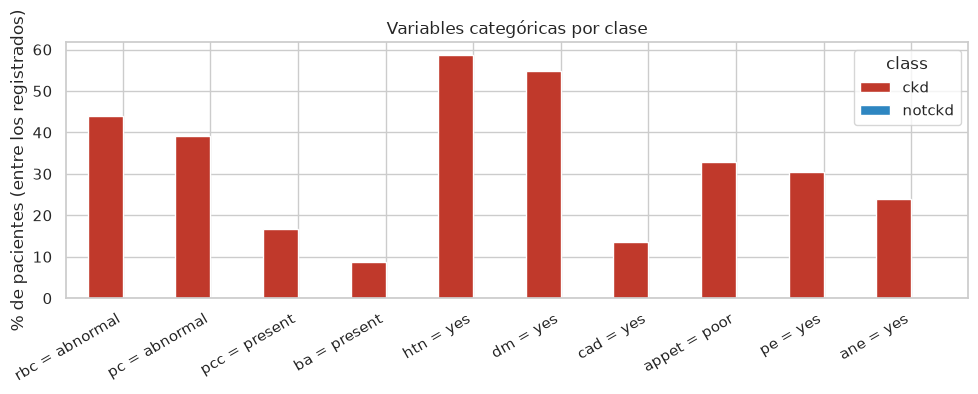

class,ckd,notckd
rbc = abnormal,43.9,0.0
pc = abnormal,39.2,0.0
pcc = present,16.8,0.0
ba = present,8.8,0.0
htn = yes,58.8,0.0
dm = yes,54.8,0.0
cad = yes,13.6,0.0
appet = poor,32.8,0.0
pe = yes,30.4,0.0
ane = yes,24.0,0.0


In [12]:
POSITIVO = {"rbc": "abnormal", "pc": "abnormal", "pcc": "present", "ba": "present", "htn": "yes",
            "dm": "yes", "cad": "yes", "appet": "poor", "pe": "yes", "ane": "yes"}
prop = pd.DataFrame({c: df.dropna(subset=[c]).groupby(TARGET)[c].apply(lambda s: (s == POSITIVO[c]).mean())
                     for c in CAT_COLS}).T * 100
prop.index = [f"{c} = {POSITIVO[c]}" for c in CAT_COLS]
fig, ax = plt.subplots(figsize=(10, 4))
prop[["ckd", "notckd"]].plot.bar(ax=ax, color=[PALETA["ckd"], PALETA["notckd"]], width=0.8)
ax.set_ylabel("% de pacientes (entre los registrados)"); ax.set_title("Variables categóricas por clase")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); guardar(fig, "05_categoricas"); plt.show()
display(prop.round(1))

**Interpretación.** Hipertensión (`htn`), diabetes (`dm`), anemia (`ane`), edema pedal (`pe`) y apetito pobre (`appet`) aparecen **solo o casi solo** en pacientes con ERC, en línea con los factores de riesgo y síntomas conocidos [2]. En los `notckd` estas condiciones son prácticamente nulas, lo que refuerza la alta separabilidad de las clases.

### 3.5 Matriz de correlación

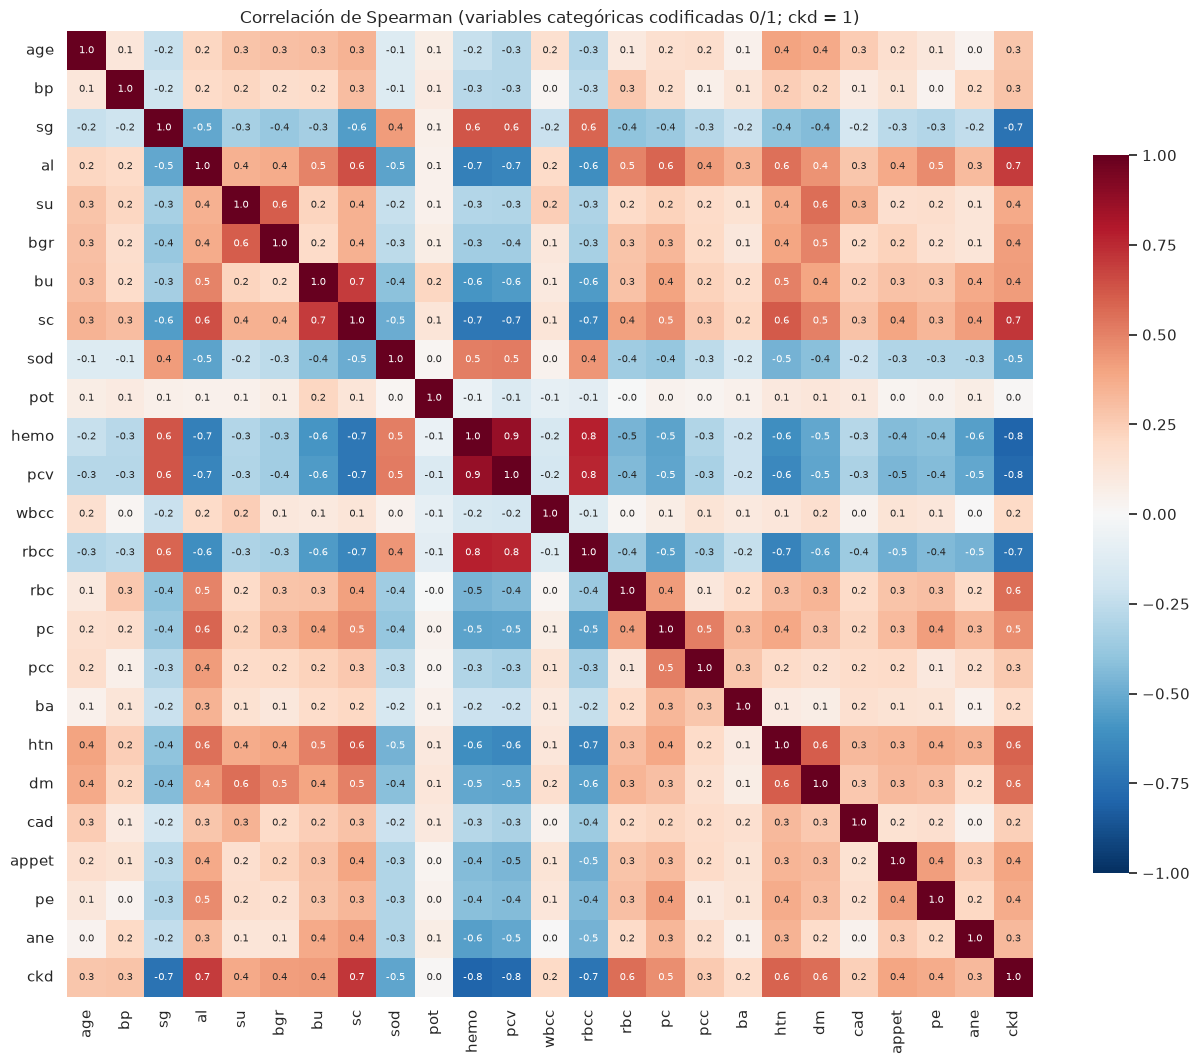

,corr. con ckd
hemo,-0.80
pcv,-0.78
sg,-0.74
rbcc,-0.73
sc,0.71
al,0.70
htn,0.59
dm,0.56
rbc,0.56
sod,-0.53


In [13]:
df_cod = df.copy()
for c in CAT_COLS:
    df_cod[c] = (df[c] == POSITIVO[c]).astype(float).where(df[c].notna())
df_cod["ckd"] = (df[TARGET] == "ckd").astype(float)
corr = df_cod.drop(columns=TARGET).corr(method="spearman")   # correlación por pares disponibles
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, annot=True, fmt=".1f",
            annot_kws={"size": 7}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlación de Spearman (variables categóricas codificadas 0/1; ckd = 1)")
plt.tight_layout(); guardar(fig, "06_correlacion"); plt.show()
display(corr["ckd"].drop("ckd").sort_values(key=abs, ascending=False).round(2).head(12).to_frame("corr. con ckd"))

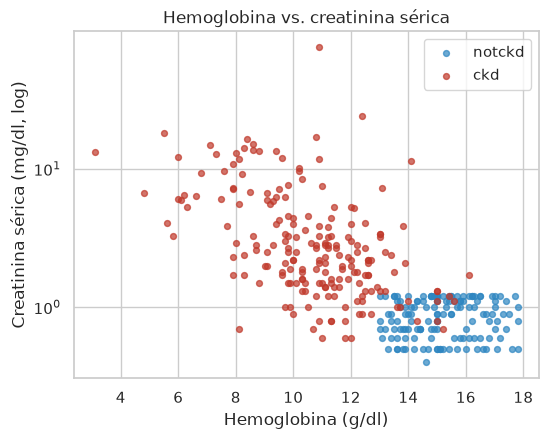

In [14]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for clase in ["notckd", "ckd"]:
    d = df[df[TARGET] == clase]
    ax.scatter(d["hemo"], d["sc"], s=18, alpha=0.7, color=PALETA[clase], label=clase)
ax.set_yscale("log"); ax.set_xlabel("Hemoglobina (g/dl)"); ax.set_ylabel("Creatinina sérica (mg/dl, log)")
ax.set_title("Hemoglobina vs. creatinina sérica"); ax.legend()
guardar(fig, "07_dispersion_hemo_sc"); plt.show()

**Interpretación.** Las variables más correlacionadas con la ERC son `hemo`, `pcv`, `sg`, `rbcc` (negativamente) y `al`, `htn`, `sc`, `bu`, `dm` (positivamente). Existe **colinealidad** entre `hemo`, `pcv` y `rbcc` (las tres miden la serie roja) y entre `sc` y `bu` (función renal), algo a considerar al interpretar coeficientes de la Regresión Logística (por eso se usa regularización). El diagrama de dispersión `hemo` vs. `sc` muestra que con solo dos variables las clases ya quedan casi separadas.

## 4. Preprocesamiento de los datos (§6)

| Paso | Decisión | Justificación |
|---|---|---|
| Limpieza de formato | Quitar espacios/tabulaciones, `?` → `NaN`, conversión numérica | Errores de registro en la fuente; no se aprende nada de los datos. |
| Eliminación de atributos | **Ninguno** en el modelo principal | 24 variables con sentido clínico; pocas en relación con 400 instancias. (La eliminación de columnas se evalúa como alternativa en la Sección 9.) |
| Variables ordinales `sg`, `al`, `su` | Se tratan como numéricas | Tienen orden natural; one-hot perdería esa información. |
| Categóricas binarias | Codificación 0/1 (`OrdinalEncoder` con categorías explícitas, p. ej. `normal`=0, `abnormal`=1) | Son binarias: 0/1 equivale a one-hot con `drop='if_binary'` y conserva los `NaN` para imputarlos después. |
| Estandarización | `StandardScaler` (media 0, desvío 1) | Imprescindible para Regresión Logística regularizada, SVM (kernel RBF basado en distancias) y la red neuronal (convergencia del optimizador). Irrelevante pero inocuo para Random Forest. |
| Valores faltantes | **Modelo principal:** imputación por **mediana** (en variables binarias la mediana equivale a la moda) | Robusta a los outliers de `sc`, `bu`, `bgr`. Otras 5 estrategias se comparan en la Sección 9. |
| Outliers | Se conservan | Valores extremos de `sc`/`bu` son clínicamente reales y muy informativos. |
| Desbalance | Estratificación + métricas F1/Recall/AUC; `class_weight` como hiperparámetro | Desbalance moderado (62,5/37,5); no se generan datos sintéticos. |

**Prevención de *data leakage*.** Todos los pasos que aprenden parámetros de los datos (medianas, medias/desvíos, columnas a eliminar, vecinos de KNN) se encapsulan en un `Pipeline` de scikit-learn junto con el modelo. Así, en cada *fold* de validación cruzada el preprocesamiento se ajusta solo con los datos de entrenamiento de ese *fold*, y sobre Test solo se aplica `transform`.

In [15]:
# Codificación explícita de las categóricas (0 = valor "normal", 1 = valor "anormal")
CATEGORIAS = {"rbc": ["normal", "abnormal"], "pc": ["normal", "abnormal"],
              "pcc": ["notpresent", "present"], "ba": ["notpresent", "present"],
              "htn": ["no", "yes"], "dm": ["no", "yes"], "cad": ["no", "yes"],
              "appet": ["good", "poor"], "pe": ["no", "yes"], "ane": ["no", "yes"]}


class EliminarColumnasFaltantes(BaseEstimator, TransformerMixin):
    # Elimina las columnas cuya proporción de faltantes EN EL TRAIN supera un umbral.
    def __init__(self, umbral=0.20):
        self.umbral = umbral

    def fit(self, X, y=None):
        self.mantener_ = np.isnan(np.asarray(X, dtype=float)).mean(axis=0) <= self.umbral
        return self

    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.mantener_]


def construir_preprocesador(estrategia="mediana"):
    # Codificación -> estandarización -> tratamiento de faltantes.
    # StandardScaler ignora los NaN al calcular media/desvío, por lo que se aplica antes de imputar
    # (necesario para que las distancias de KNN sean comparables entre variables).
    codificar = ColumnTransformer(
        [("num", "passthrough", NUM_COLS),
         ("cat", OrdinalEncoder(categories=[CATEGORIAS[c] for c in CAT_COLS],
                                handle_unknown="use_encoded_value", unknown_value=np.nan,
                                encoded_missing_value=np.nan), CAT_COLS)])
    pasos = [("codificar", codificar), ("escalar", StandardScaler())]
    if estrategia == "mediana":
        pasos.append(("imputar", SimpleImputer(strategy="median")))
    elif estrategia == "mediana+indicador":
        pasos.append(("imputar", SimpleImputer(strategy="median", add_indicator=True)))
    elif estrategia == "knn":
        pasos.append(("imputar", KNNImputer(n_neighbors=5)))
    elif estrategia == "iterativa":
        pasos.append(("imputar", IterativeImputer(max_iter=15, random_state=SEED)))
    elif estrategia == "eliminar_columnas":
        pasos += [("eliminar", EliminarColumnasFaltantes(umbral=0.20)),
                  ("imputar", SimpleImputer(strategy="median"))]
    else:
        raise ValueError(estrategia)
    return Pipeline(pasos)

construir_preprocesador()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('codificar', ...), ('escalar', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

## 5. Protocolo experimental (§7)

1. **Separación Training/Test:** `train_test_split` con **80 % entrenamiento (320 pacientes) / 20 % prueba (80 pacientes)**, **estratificada** por la clase y con `random_state=42`.
2. **El conjunto de Test se aparta inmediatamente** y no se usa en el EDA de decisiones, ni en el preprocesamiento, ni en la selección de modelos/hiperparámetros. Se usa **una única vez** al final para la evaluación de los modelos ya elegidos.
3. **Selección de hiperparámetros:** `GridSearchCV` con **validación cruzada estratificada de 5 *folds*** (`StratifiedKFold`, *shuffle*, semilla fija) **solo sobre Training**. Métrica de selección: **F1-score** de la clase `ckd` (equilibra Precision y Recall; se reportan también Accuracy, Recall y AUC).
4. **Preprocesamiento dentro del Pipeline:** en cada *fold* la imputación y el escalado se ajustan solo con los *folds* de entrenamiento (evita *leakage*).
5. **Red neuronal:** la parada temprana (*early stopping*) usa una partición de validación interna (20 %) tomada **del conjunto de entrenamiento de cada ajuste**, nunca de Test.
6. **Pregunta particular (Sección 9):** las estrategias de faltantes se comparan con **validación cruzada repetida (5 *folds* × 2 repeticiones)** sobre Training y luego se reporta Test como confirmación.

Con solo 80 pacientes en Test, **cada error equivale a 1,25 puntos de Accuracy**, por eso se reportan también la media y el desvío de la validación cruzada como estimación más estable.

In [16]:
X = df[NUM_COLS + CAT_COLS]
y = (df[TARGET] == "ckd").astype(int)          # ckd = 1 (clase positiva)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

particion = pd.DataFrame({
    "Instancias": [len(X_train), len(X_test)],
    "ckd (1)": [y_train.sum(), y_test.sum()],
    "notckd (0)": [(y_train == 0).sum(), (y_test == 0).sum()],
    "% ckd": [f"{y_train.mean():.1%}", f"{y_test.mean():.1%}"],
    "% celdas faltantes": [f"{X_train.isna().mean().mean():.1%}", f"{X_test.isna().mean().mean():.1%}"],
}, index=["Training", "Test"])
display(particion)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"f1": "f1", "accuracy": "accuracy", "recall": "recall",
           "precision": "precision", "roc_auc": "roc_auc"}

,Instancias,ckd (1),notckd (0),% ckd,% celdas faltantes
Training,320,200,120,62.5%,11.1%
Test,80,50,30,62.5%,8.3%


## 6. Modelos de Machine Learning (§8) y ajuste de hiperparámetros (§9)

Se implementan los cuatro modelos exigidos. **Los cuatro** se ajustan con `GridSearchCV` (5-fold estratificado sobre Training, métrica F1), con grillas pequeñas y justificadas para que la ejecución en Colab sea rápida.

In [17]:
def ajustar(nombre, modelo, grilla, estrategia="mediana", n_jobs=-1):
    pipe = Pipeline([("prep", construir_preprocesador(estrategia)), ("modelo", modelo)])
    gs = GridSearchCV(pipe, grilla, cv=CV, scoring=SCORING, refit="f1",
                      n_jobs=n_jobs, return_train_score=True)
    t0 = time.time()
    gs.fit(X_train, y_train)
    r = gs.cv_results_; i = gs.best_index_
    print(f"{nombre}: {len(r['params'])} configuraciones x 5 folds en {time.time() - t0:.1f} s")
    print("  Mejores hiperparámetros:", {k.replace('modelo__', ''): v for k, v in gs.best_params_.items()})
    print(f"  CV  -> F1 = {r['mean_test_f1'][i]:.4f} ± {r['std_test_f1'][i]:.4f} | "
          f"Acc = {r['mean_test_accuracy'][i]:.4f} | Recall = {r['mean_test_recall'][i]:.4f} | "
          f"AUC = {r['mean_test_roc_auc'][i]:.4f}")
    print(f"  Train (media de folds) -> F1 = {r['mean_train_f1'][i]:.4f}")
    return gs

def tabla_grilla(gs, top=8):
    r = pd.DataFrame(gs.cv_results_)
    cols = [c for c in r.columns if c.startswith("param_")]
    t = r[cols + ["mean_test_f1", "std_test_f1", "mean_test_roc_auc", "mean_train_f1", "rank_test_f1"]]
    t.columns = [c.replace("param_modelo__", "") for c in t.columns]
    return t.sort_values(["rank_test_f1", "mean_test_roc_auc"], ascending=[True, False]).head(top).round(4)

busquedas = {}

### 6.1 Regresión Logística (modelo de referencia)

Modelo lineal que estima $P(\text{ckd}\mid x) = \sigma(w^\top x + b)$ [15]. Requiere variables **escaladas** (la regularización penaliza todos los coeficientes por igual) y **sin faltantes** (se imputan en el pipeline).

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `C` (inversa de la regularización) | 0.01, 0.1, 1, 10, 100 | Barrido logarítmico de fuerte a débil regularización. |
| `penalty` | `l1`, `l2` | L1 hace selección de variables (útil con variables colineales); L2 encoge coeficientes. |
| `class_weight` | `None`, `balanced` | Compensar el desbalance moderado. |

In [18]:
busquedas["Regresión Logística"] = ajustar(
    "Regresión Logística",
    LogisticRegression(solver="liblinear", max_iter=5000, random_state=SEED),
    {"modelo__C": [0.01, 0.1, 1, 10, 100], "modelo__penalty": ["l1", "l2"],
     "modelo__class_weight": [None, "balanced"]})
display(tabla_grilla(busquedas["Regresión Logística"]))

Regresión Logística: 20 configuraciones x 5 folds en 5.0 s
  Mejores hiperparámetros: {'C': 10, 'class_weight': None, 'penalty': 'l2'}
  CV  -> F1 = 0.9975 ± 0.0051 | Acc = 0.9969 | Recall = 0.9950 | AUC = 1.0000
  Train (media de folds) -> F1 = 1.0000


,C,class_weight,penalty,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_train_f1,rank_test_f1
13,10.0,NaN,l2,0.9975,0.0051,1.0000,1.0000,1
8,1.0,NaN,l1,0.9949,0.0103,1.0000,1.0000,2
17,100.0,NaN,l2,0.9926,0.0098,1.0000,1.0000,3
19,100.0,balanced,l2,0.9923,0.0102,1.0000,1.0000,4
9,1.0,NaN,l2,0.9898,0.0096,0.9998,0.9994,5
10,1.0,balanced,l1,0.9871,0.0142,1.0000,0.9987,6
15,10.0,balanced,l2,0.9871,0.0142,1.0000,1.0000,6
14,10.0,balanced,l1,0.9847,0.0128,1.0000,1.0000,8


### 6.2 Support Vector Machine

Busca el hiperplano de **margen máximo** [6]; con el *kernel trick* (RBF) puede construir fronteras no lineales. Es sensible a la escala, por lo que la estandarización es obligatoria.

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `kernel` | `linear`, `rbf` | El EDA sugiere separabilidad casi lineal; RBF permite verificar si una frontera no lineal aporta. |
| `C` | 0.1, 1, 10, 100 | Compromiso margen amplio (C bajo) vs. clasificar bien todo el train (C alto). |
| `gamma` (solo RBF) | `scale`, 0.01, 0.1 | Alcance de cada vector soporte; valores altos → fronteras más complejas (riesgo de sobreajuste). |

Se usa `probability=True` para obtener probabilidades (curva ROC/AUC).

In [19]:
busquedas["SVM"] = ajustar(
    "SVM",
    SVC(probability=True, random_state=SEED),
    [{"modelo__kernel": ["linear"], "modelo__C": [0.1, 1, 10, 100]},
     {"modelo__kernel": ["rbf"], "modelo__C": [0.1, 1, 10, 100], "modelo__gamma": ["scale", 0.01, 0.1]}])
display(tabla_grilla(busquedas["SVM"]))

SVM: 16 configuraciones x 5 folds en 2.5 s
  Mejores hiperparámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  CV  -> F1 = 0.9975 ± 0.0051 | Acc = 0.9969 | Recall = 0.9950 | AUC = 1.0000
  Train (media de folds) -> F1 = 1.0000


,C,kernel,gamma,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_train_f1,rank_test_f1
10,10.0,rbf,scale,0.9975,0.0051,1.0000,1.0000,1
12,10.0,rbf,0.1,0.9950,0.0061,0.9998,1.0000,2
15,100.0,rbf,0.1,0.9950,0.0061,0.9998,1.0000,2
7,1.0,rbf,scale,0.9949,0.0062,1.0000,0.9969,4
9,1.0,rbf,0.1,0.9949,0.0062,1.0000,0.9981,4
11,10.0,rbf,0.01,0.9949,0.0062,0.9998,0.9994,4
0,0.1,linear,NaN,0.9949,0.0062,0.9994,0.9987,4
14,100.0,rbf,0.01,0.9925,0.0100,0.9998,1.0000,8


### 6.3 Sistema ensamblado: Random Forest

**Justificación de la elección.** Random Forest [7] combina muchos árboles de decisión entrenados sobre muestras *bootstrap* y subconjuntos aleatorios de variables (*bagging*), y promedia sus votos. Es adecuado para este caso porque: (i) maneja naturalmente la mezcla de variables numéricas y binarias sin requerir escalado; (ii) es robusto a outliers (`sc`, `bu`) y a variables colineales (`hemo`/`pcv`/`rbcc`); (iii) al promediar árboles reduce la varianza, lo que es valioso con solo 320 instancias de entrenamiento; y (iv) entrega importancias de variables interpretables. Además, es el modelo con mejores resultados reportados en este dataset [4].

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `n_estimators` | 200, 500 | Más árboles estabilizan el voto (sin sobreajustar). |
| `max_depth` | `None`, 5 | Árboles completos vs. poco profundos (control de complejidad). |
| `min_samples_leaf` | 1, 3 | Hojas más grandes suavizan la frontera. |
| `max_features` | `sqrt`, 0.5 | Grado de decorrelación entre árboles. |

In [20]:
busquedas["Random Forest"] = ajustar(
    "Random Forest",
    RandomForestClassifier(random_state=SEED, n_jobs=1),
    {"modelo__n_estimators": [200, 500], "modelo__max_depth": [None, 5],
     "modelo__min_samples_leaf": [1, 3], "modelo__max_features": ["sqrt", 0.5]})
display(tabla_grilla(busquedas["Random Forest"]))

Random Forest: 16 configuraciones x 5 folds en 19.6 s
  Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
  CV  -> F1 = 0.9951 ± 0.0060 | Acc = 0.9938 | Recall = 1.0000 | AUC = 0.9992
  Train (media de folds) -> F1 = 1.0000


,max_depth,max_features,min_samples_leaf,n_estimators,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_train_f1,rank_test_f1
0,None,sqrt,1,200,0.9951,0.0060,0.9992,1.0000,1
1,None,sqrt,1,500,0.9927,0.0098,0.9992,1.0000,2
8,5,sqrt,1,200,0.9927,0.0098,0.9992,0.9975,2
9,5,sqrt,1,500,0.9927,0.0098,0.9992,0.9956,2
13,5,0.5,1,500,0.9927,0.0098,0.9979,0.9988,2
10,5,sqrt,3,200,0.9901,0.0144,0.9988,0.9950,6
2,None,sqrt,3,200,0.9901,0.0144,0.9985,0.9950,6
5,None,0.5,1,500,0.9901,0.0144,0.9979,1.0000,6


### 6.4 Red Neuronal (perceptrón multicapa con Keras/TensorFlow)

Se implementa una red **densa sencilla** [9] y se envuelve en una clase compatible con scikit-learn (`KerasMLP`) para poder usarla **dentro del mismo Pipeline** (mismo preprocesamiento sin *leakage*) y de `GridSearchCV`.

**Arquitectura:**
- Entrada: 24 variables preprocesadas (imputadas y estandarizadas).
- Capas ocultas densas con activación **ReLU** (número de neuronas a ajustar), cada una seguida de **Dropout** [17] para regularizar (dataset pequeño → riesgo de sobreajuste).
- Salida: 1 neurona **sigmoide** → $P(\text{ckd})$.
- Función de pérdida: **entropía cruzada binaria** (*binary cross-entropy*).
- Optimizador: **Adam** [16], tasa de aprendizaje 0.003 (con 0.001 la red no alcanzaba a converger dentro del límite de épocas).
- Hasta **300 épocas**, *batch size* **32**, con **Early Stopping** (paciencia 20 sobre la pérdida de validación interna, restaurando los mejores pesos).

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `capas_ocultas` | (8,), (16, 8), (32, 16) | De una capa pequeña a dos capas: complejidad creciente pero acotada. |
| `dropout` | 0.0, 0.3 | Sin regularización vs. regularización moderada. |

In [21]:
class KerasMLP(ClassifierMixin, BaseEstimator):
    # Red neuronal densa (Keras) con interfaz scikit-learn: fit / predict / predict_proba.

    def __init__(self, capas_ocultas=(16, 8), dropout=0.3, learning_rate=3e-3, epochs=300,
                 batch_size=32, patience=20, validation_size=0.2, random_state=SEED, verbose=0):
        self.capas_ocultas = capas_ocultas
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.patience = patience
        self.validation_size = validation_size
        self.random_state = random_state
        self.verbose = verbose

    def _construir(self, n_entradas):
        tf.keras.utils.set_random_seed(self.random_state)
        modelo = keras.Sequential([keras.Input(shape=(n_entradas,))])
        for n in self.capas_ocultas:
            modelo.add(layers.Dense(n, activation="relu"))
            if self.dropout > 0:
                modelo.add(layers.Dropout(self.dropout))
        modelo.add(layers.Dense(1, activation="sigmoid"))
        modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate),
                       loss="binary_crossentropy", metrics=["accuracy"])
        return modelo

    def fit(self, X, y):
        X = np.asarray(X, dtype="float32"); y = np.asarray(y, dtype="float32")
        self.classes_ = np.array([0, 1])
        self.n_features_in_ = X.shape[1]
        # Validación interna estratificada tomada del conjunto de ENTRENAMIENTO recibido
        X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=self.validation_size,
                                                    stratify=y, random_state=self.random_state)
        self.model_ = self._construir(X.shape[1])
        parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=self.patience,
                                               restore_best_weights=True)
        # tf.data con caché: mismo resultado que pasar arrays, pero bastante más rápido en CPU
        datos_tr = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                    .shuffle(len(X_tr), seed=self.random_state, reshuffle_each_iteration=True)
                    .batch(self.batch_size))
        datos_val = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(256).cache()
        self.history_ = self.model_.fit(datos_tr, validation_data=datos_val, epochs=self.epochs,
                                        callbacks=[parada], verbose=self.verbose).history
        return self

    def predict_proba(self, X):
        p = self.model_(np.asarray(X, dtype="float32"), training=False).numpy().ravel()
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


busquedas["Red Neuronal"] = ajustar(
    "Red Neuronal", KerasMLP(),
    {"modelo__capas_ocultas": [(8,), (16, 8), (32, 16)], "modelo__dropout": [0.0, 0.3]},
    n_jobs=1)
display(tabla_grilla(busquedas["Red Neuronal"]))

Red Neuronal: 6 configuraciones x 5 folds en 240.0 s
  Mejores hiperparámetros: {'capas_ocultas': (8,), 'dropout': 0.3}
  CV  -> F1 = 0.9949 ± 0.0062 | Acc = 0.9938 | Recall = 0.9900 | AUC = 1.0000
  Train (media de folds) -> F1 = 0.9981


,capas_ocultas,dropout,mean_test_f1,std_test_f1,mean_test_roc_auc,mean_train_f1,rank_test_f1
1,"(8,)",0.3,0.9949,0.0062,1.0,0.9981,1
2,"(16, 8)",0.0,0.9949,0.0062,1.0,0.9994,1
3,"(16, 8)",0.3,0.9923,0.0102,1.0,0.9994,3
4,"(32, 16)",0.0,0.9923,0.0102,1.0,1.0000,3
5,"(32, 16)",0.3,0.9897,0.0151,1.0,1.0000,5
0,"(8,)",0.0,0.9848,0.0150,1.0,0.9975,6


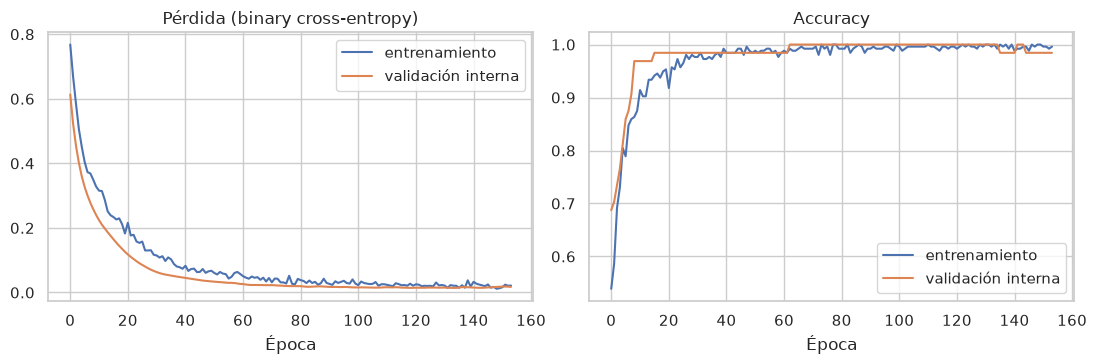

Épocas ejecutadas: 154 (mejor época según val_loss: 134)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 420 (1.64 KB)

In [22]:
# Curvas de aprendizaje de la red final (re-entrenada con todo Training por GridSearchCV)
red = busquedas["Red Neuronal"].best_estimator_.named_steps["modelo"]
h = red.history_
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(h["loss"], label="entrenamiento"); axes[0].plot(h["val_loss"], label="validación interna")
axes[0].set_title("Pérdida (binary cross-entropy)"); axes[0].set_xlabel("Época"); axes[0].legend()
axes[1].plot(h["accuracy"], label="entrenamiento"); axes[1].plot(h["val_accuracy"], label="validación interna")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Época"); axes[1].legend()
plt.tight_layout(); guardar(fig, "08_curvas_red"); plt.show()
print(f"Épocas ejecutadas: {len(h['loss'])} (mejor época según val_loss: {int(np.argmin(h['val_loss'])) + 1})")
red.model_.summary()

### 6.5 Resumen del ajuste de hiperparámetros

In [23]:
filas = []
for nombre, gs in busquedas.items():
    r = gs.cv_results_; i = gs.best_index_
    filas.append({
        "Modelo": nombre,
        "Configuraciones": len(r["params"]),
        "Mejores hiperparámetros": {k.replace("modelo__", ""): v for k, v in gs.best_params_.items()},
        "F1 CV (media ± desvío)": f"{r['mean_test_f1'][i]:.3f} ± {r['std_test_f1'][i]:.3f}",
        "AUC CV": round(r["mean_test_roc_auc"][i], 4),
        "F1 train": round(r["mean_train_f1"][i], 4),
    })
resumen_hp = pd.DataFrame(filas).set_index("Modelo")
display(resumen_hp)

,Configuraciones,Mejores hiperparámetros,F1 CV (media ± desvío),AUC CV,F1 train
Modelo,,,,,
Regresión Logística,20,"{'C': 10, 'class_weight': None, 'penalty': 'l2'}",0.997 ± 0.005,1.0000,1.0000
SVM,16,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.997 ± 0.005,1.0000,1.0000
Random Forest,16,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.995 ± 0.006,0.9992,1.0000
Red Neuronal,6,"{'capas_ocultas': (8,), 'dropout': 0.3}",0.995 ± 0.006,1.0000,0.9981


## 7. Evaluación de los modelos sobre Test (§10)

Los modelos finales (mejor configuración de cada búsqueda, re-entrenada con **todo** el conjunto de Training) se evalúan **una única vez** sobre el conjunto de Test.

**Qué mide cada métrica (clase positiva = `ckd`):**
- **Accuracy:** proporción total de aciertos. Puede ser engañosa con clases desbalanceadas.
- **Precision:** de los pacientes que el modelo marca como ERC, cuántos realmente la tienen (costo de falsas alarmas → estudios innecesarios).
- **Recall (sensibilidad):** de los pacientes con ERC, cuántos detecta el modelo. **Es la métrica más importante en tamizaje**, porque un falso negativo retrasa el diagnóstico y el tratamiento.
- **Especificidad:** de los pacientes sanos, cuántos se clasifican como sanos.
- **F1-score:** media armónica de Precision y Recall; resume ambos en un solo número.
- **Matriz de confusión:** muestra explícitamente VP, VN, FP y FN.
- **AUC-ROC:** probabilidad de que el modelo asigne mayor puntaje a un enfermo que a un sano, independiente del umbral de decisión [18].

In [24]:
modelos_finales = {n: gs.best_estimator_ for n, gs in busquedas.items()}

def metricas(y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred),
            "Especificidad": tn / (tn + fp),
            "F1-score": f1_score(y_true, y_pred),
            "AUC": roc_auc_score(y_true, y_score),
            "FN": fn, "FP": fp}

res_test, predicciones = {}, {}
for nombre, modelo in modelos_finales.items():
    p = modelo.predict_proba(X_test)[:, 1]
    yp = (p >= 0.5).astype(int)
    predicciones[nombre] = (yp, p)
    res_test[nombre] = metricas(y_test, yp, p)
    print(f"===== {nombre} =====")
    print(classification_report(y_test, yp, target_names=["notckd (0)", "ckd (1)"], digits=3))

===== Regresión Logística =====
              precision    recall  f1-score   support

  notckd (0)      0.938     1.000     0.968        30
     ckd (1)      1.000     0.960     0.980        50

    accuracy                          0.975        80
   macro avg      0.969     0.980     0.974        80
weighted avg      0.977     0.975     0.975        80

===== SVM =====
              precision    recall  f1-score   support

  notckd (0)      0.968     1.000     0.984        30
     ckd (1)      1.000     0.980     0.990        50

    accuracy                          0.988        80
   macro avg      0.984     0.990     0.987        80
weighted avg      0.988     0.988     0.988        80



===== Random Forest =====
              precision    recall  f1-score   support

  notckd (0)      1.000     1.000     1.000        30
     ckd (1)      1.000     1.000     1.000        50

    accuracy                          1.000        80
   macro avg      1.000     1.000     1.000        80
weighted avg      1.000     1.000     1.000        80

===== Red Neuronal =====
              precision    recall  f1-score   support

  notckd (0)      0.909     1.000     0.952        30
     ckd (1)      1.000     0.940     0.969        50

    accuracy                          0.963        80
   macro avg      0.955     0.970     0.961        80
weighted avg      0.966     0.963     0.963        80



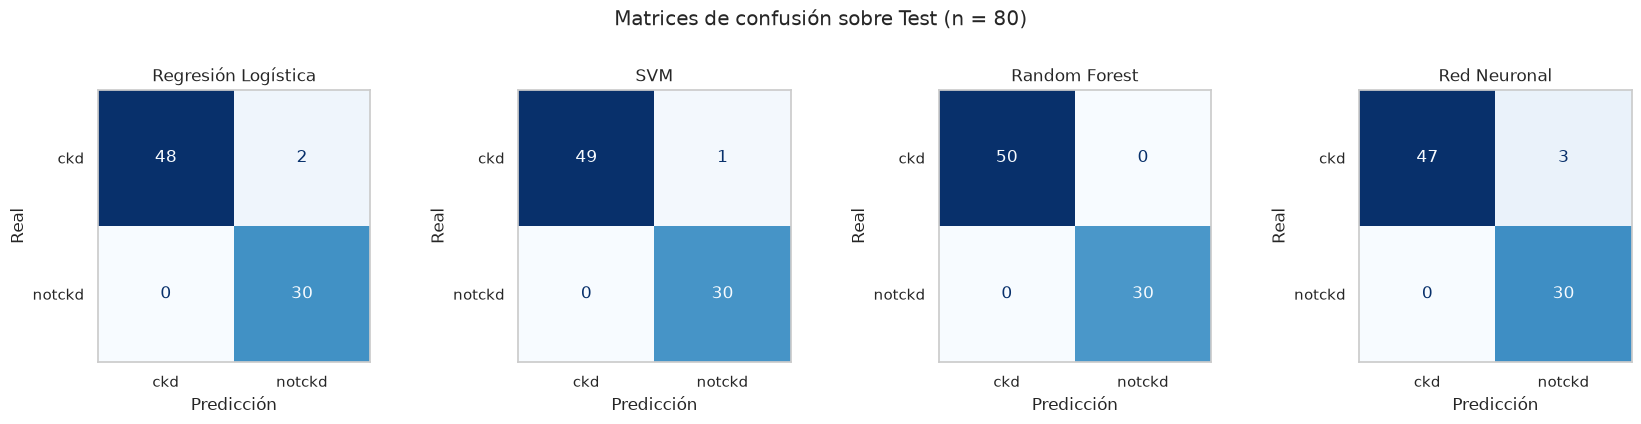

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, (nombre, (yp, _)) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, yp, labels=[1, 0])
    ConfusionMatrixDisplay(cm, display_labels=["ckd", "notckd"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre); ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
    ax.grid(False)
fig.suptitle("Matrices de confusión sobre Test (n = 80)", y=1.03)
plt.tight_layout(); guardar(fig, "09_matrices_confusion"); plt.show()

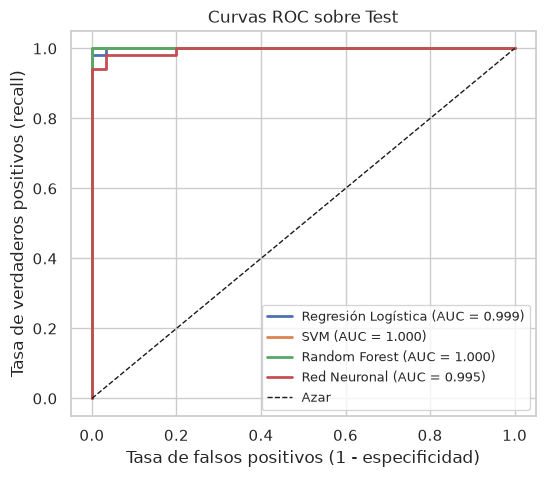

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
for nombre, (_, p) in predicciones.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC = {roc_auc_score(y_test, p):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Azar")
ax.set_xlabel("Tasa de falsos positivos (1 - especificidad)"); ax.set_ylabel("Tasa de verdaderos positivos (recall)")
ax.set_title("Curvas ROC sobre Test"); ax.legend(loc="lower right", fontsize=9)
guardar(fig, "10_curvas_roc"); plt.show()

## 8. Comparación de los modelos (§11)

### 8.1 Tabla comparativa

In [27]:
tabla_test = pd.DataFrame(res_test).T
tabla_test["F1 CV (media ± desvío)"] = resumen_hp["F1 CV (media ± desvío)"]
tabla_test["F1 train"] = resumen_hp["F1 train"]
cols = ["Accuracy", "Precision", "Recall", "Especificidad", "F1-score", "AUC"]
tabla_comparativa = tabla_test[cols + ["FN", "FP", "F1 CV (media ± desvío)", "F1 train"]]
tabla_comparativa[cols] = tabla_comparativa[cols].astype(float).round(4)
tabla_comparativa[["FN", "FP"]] = tabla_comparativa[["FN", "FP"]].astype(int)
tabla_comparativa.index.name = "Modelo"
display(tabla_comparativa)
tabla_comparativa.to_csv(FIG_DIR / "tabla_comparativa.csv")

,Accuracy,Precision,Recall,Especificidad,F1-score,AUC,FN,FP,F1 CV (media ± desvío),F1 train
Modelo,,,,,,,,,,
Regresión Logística,0.9750,1.0,0.96,1.0,0.9796,0.9993,2,0,0.997 ± 0.005,1.0000
SVM,0.9875,1.0,0.98,1.0,0.9899,1.0000,1,0,0.997 ± 0.005,1.0000
Random Forest,1.0000,1.0,1.00,1.0,1.0000,1.0000,0,0,0.995 ± 0.006,1.0000
Red Neuronal,0.9625,1.0,0.94,1.0,0.9691,0.9947,3,0,0.995 ± 0.006,0.9981


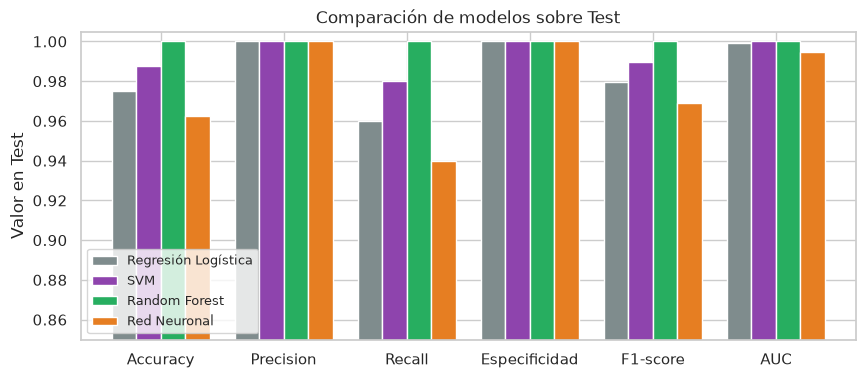

In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
tabla_comparativa[cols].T.plot.bar(ax=ax, width=0.8, color=["#7F8C8D", "#8E44AD", "#27AE60", "#E67E22"])
ax.set_ylim(0.85, 1.005); ax.set_ylabel("Valor en Test"); ax.set_title("Comparación de modelos sobre Test")
ax.legend(loc="lower left", fontsize=9); plt.xticks(rotation=0)
guardar(fig, "11_comparacion_modelos"); plt.show()

### 8.2 Sobreajuste y capacidad de generalización

Se compara el desempeño en entrenamiento, en validación cruzada (estimación de generalización con 5 × 64 pacientes) y en Test (80 pacientes nunca vistos). Una brecha grande entre train y CV/Test indicaría sobreajuste.

In [29]:
gen = pd.DataFrame({
    "F1 train": [gs.cv_results_["mean_train_f1"][gs.best_index_] for gs in busquedas.values()],
    "F1 CV": [gs.cv_results_["mean_test_f1"][gs.best_index_] for gs in busquedas.values()],
    "F1 Test": [res_test[n]["F1-score"] for n in busquedas],
    "Acc CV": [gs.cv_results_["mean_test_accuracy"][gs.best_index_] for gs in busquedas.values()],
    "Acc Test": [res_test[n]["Accuracy"] for n in busquedas],
}, index=list(busquedas)).round(4)
gen["Brecha F1 (train - CV)"] = (gen["F1 train"] - gen["F1 CV"]).round(4)
display(gen)

,F1 train,F1 CV,F1 Test,Acc CV,Acc Test,Brecha F1 (train - CV)
Regresión Logística,1.0000,0.9975,0.9796,0.9969,0.9750,0.0025
SVM,1.0000,0.9975,0.9899,0.9969,0.9875,0.0025
Random Forest,1.0000,0.9951,1.0000,0.9938,1.0000,0.0049
Red Neuronal,0.9981,0.9949,0.9691,0.9938,0.9625,0.0032


### 8.3 Análisis de errores de clasificación

Se inspeccionan los pacientes de Test mal clasificados por al menos un modelo.

In [30]:
errores = pd.DataFrame({n: yp for n, (yp, _) in predicciones.items()}, index=X_test.index)
mal = errores.ne(y_test, axis=0)
ids = mal.index[mal.any(axis=1)]
if len(ids):
    detalle = X_test.loc[ids, ["hemo", "pcv", "sc", "bu", "sg", "al", "htn", "dm", "rbcc"]].copy()
    detalle["n_faltantes"] = X_test.loc[ids].isna().sum(axis=1)
    detalle["real"] = y_test.loc[ids].map({1: "ckd", 0: "notckd"})
    detalle["modelos que fallan"] = mal.loc[ids].apply(lambda r: ", ".join(r.index[r]), axis=1)
    for n, (_, p) in predicciones.items():
        detalle[f"P(ckd) {n[:3]}"] = pd.Series(p, index=X_test.index).loc[ids].round(2)
    display(detalle)
else:
    print("Ningún modelo cometió errores en Test.")
print("Referencia - medianas de la clase notckd:", df[df[TARGET] == "notckd"][["hemo", "pcv", "sc", "bu", "sg"]].median().to_dict())

,hemo,pcv,sc,bu,sg,al,htn,dm,rbcc,n_faltantes,real,modelos que fallan,P(ckd) Reg,P(ckd) SVM,P(ckd) Ran,P(ckd) Red
102,13.9,52.0,2.1,32.0,1.010,0.0,no,no,NaN,2,ckd,"Regresión Logística, SVM, Red Neuronal",0.39,0.46,0.72,0.09
61,NaN,NaN,32.0,391.0,1.010,1.0,no,no,NaN,4,ckd,Red Neuronal,0.58,1.00,0.90,0.00
91,16.1,52.0,1.7,26.0,1.015,4.0,no,no,5.6,0,ckd,"Regresión Logística, Red Neuronal",0.24,0.99,0.95,0.10


Referencia - medianas de la clase notckd: {'hemo': 15.0, 'pcv': 46.0, 'sc': 0.9, 'bu': 33.0, 'sg': 1.02}


### 8.4 Importancia de las variables

Se muestran los coeficientes de la Regresión Logística (variables estandarizadas → coeficientes comparables) y la importancia por permutación del Random Forest (caída del F1 al desordenar cada variable; calculada sobre Training mediante 10 repeticiones, solo con fines interpretativos).

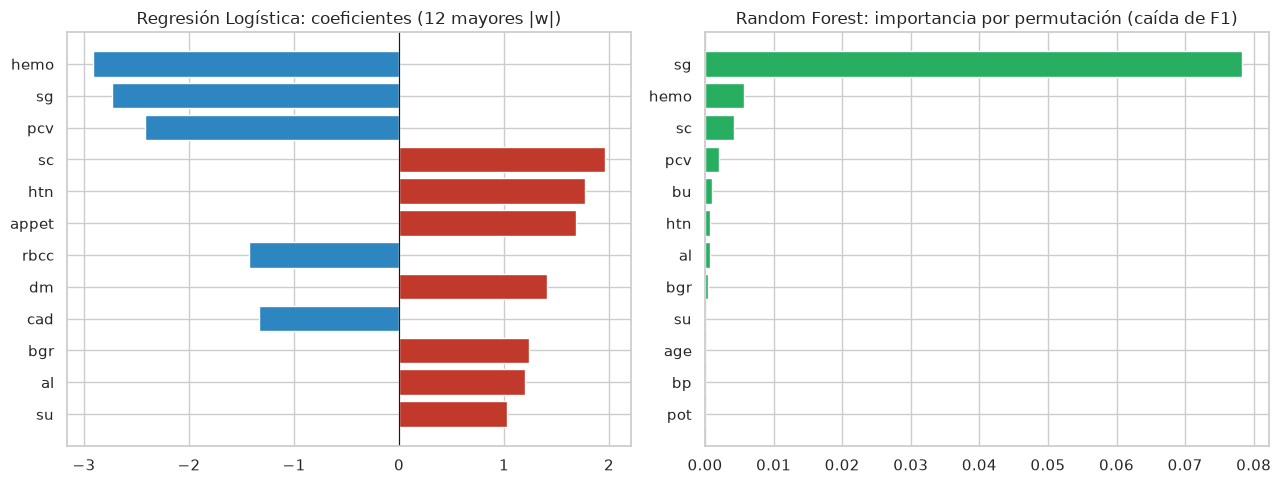

Variables con coeficiente exactamente 0 en la Regresión Logística: []


In [31]:
nombres = NUM_COLS + CAT_COLS
lr = modelos_finales["Regresión Logística"].named_steps["modelo"]
coef = pd.Series(lr.coef_.ravel(), index=nombres).sort_values(key=abs, ascending=False)

perm = permutation_importance(modelos_finales["Random Forest"], X_train, y_train, scoring="f1",
                              n_repeats=10, random_state=SEED, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=nombres).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
c = coef.head(12)[::-1]
axes[0].barh(c.index, c.values, color=["#C0392B" if v > 0 else "#2E86C1" for v in c.values])
axes[0].set_title("Regresión Logística: coeficientes (12 mayores |w|)"); axes[0].axvline(0, color="k", lw=0.8)
i12 = imp.head(12)[::-1]
axes[1].barh(i12.index, i12.values, color="#27AE60")
axes[1].set_title("Random Forest: importancia por permutación (caída de F1)")
plt.tight_layout(); guardar(fig, "12_importancia_variables"); plt.show()
print("Variables con coeficiente exactamente 0 en la Regresión Logística:", list(coef[coef == 0].index))

## 9. Pregunta particular: ¿cómo afecta el tratamiento de los valores faltantes al desempeño final de los modelos?

### 9.1 Diseño del experimento

Se comparan **seis estrategias** de tratamiento de faltantes, manteniendo fijos los **hiperparámetros óptimos** hallados en la Sección 6 para cada modelo (así, la única diferencia entre experimentos es el tratamiento de faltantes):

| # | Estrategia | Descripción |
|---|---|---|
| E1 | **Eliminar filas incompletas** (*complete-case*) | Se entrena solo con los pacientes sin ningún faltante. Para poder predecir sobre pacientes incompletos (validación/Test) se imputa con la mediana del train reducido. |
| E2 | **Eliminar columnas** con > 20 % faltantes + mediana | Umbral calculado solo con el train de cada *fold* (elimina típicamente `rbc`, `rbcc`, `wbcc`, `pot`, `sod`). |
| E3 | **Mediana / moda** (modelo principal) | Imputación univariada simple. |
| E4 | **Mediana + indicadores de faltante** | Además de imputar, agrega una variable 0/1 por cada columna con faltantes (`add_indicator=True`). El modelo "ve" qué dato faltaba. |
| E5 | **KNN** (k = 5) | Imputa con el promedio de los 5 pacientes más parecidos (en el espacio estandarizado) [13]. |
| E6 | **Iterativa (tipo MICE)** | Cada variable con faltantes se modela como regresión de las demás, iterativamente [12]. |

**Protocolo:** validación cruzada estratificada **repetida 5 *folds* × 2** (10 particiones) sobre Training. **En todas las estrategias se evalúa sobre los mismos *folds* de validación completos** (incluidos pacientes incompletos); en E1 solo se reduce el conjunto con el que se entrena. Luego se confirma en Test.

In [32]:
ESTRATEGIAS = {
    "E1 Eliminar filas": "eliminar_filas",
    "E2 Eliminar columnas": "eliminar_columnas",
    "E3 Mediana/moda": "mediana",
    "E4 Mediana + indicador": "mediana+indicador",
    "E5 KNN (k=5)": "knn",
    "E6 Iterativa (MICE)": "iterativa",
}
CV_REP = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

def pipeline_con_estrategia(nombre_modelo, estrategia):
    modelo = clone(modelos_finales[nombre_modelo].named_steps["modelo"])
    prep = construir_preprocesador("mediana" if estrategia == "eliminar_filas" else estrategia)
    return Pipeline([("prep", prep), ("modelo", modelo)])

def ajustar_con_estrategia(pipe, estrategia, X_fit, y_fit):
    if estrategia == "eliminar_filas":
        completas = X_fit.notna().all(axis=1)
        X_fit, y_fit = X_fit[completas], y_fit[completas]
    return pipe.fit(X_fit, y_fit), len(X_fit), y_fit.mean()

def evaluar(pipe, X_eval, y_eval):
    p = pipe.predict_proba(X_eval)[:, 1]; yp = (p >= 0.5).astype(int)
    return {"F1": f1_score(y_eval, yp), "Accuracy": accuracy_score(y_eval, yp),
            "Recall": recall_score(y_eval, yp), "Precision": precision_score(y_eval, yp, zero_division=0),
            "AUC": roc_auc_score(y_eval, p)}

t0 = time.time()
registros = []
for nombre_modelo in modelos_finales:
    for etiqueta, estrategia in ESTRATEGIAS.items():
        for k, (itr, iva) in enumerate(CV_REP.split(X_train, y_train)):
            pipe = pipeline_con_estrategia(nombre_modelo, estrategia)
            pipe, n_fit, prop_ckd = ajustar_con_estrategia(pipe, estrategia, X_train.iloc[itr], y_train.iloc[itr])
            m = evaluar(pipe, X_train.iloc[iva], y_train.iloc[iva])
            registros.append({"Modelo": nombre_modelo, "Estrategia": etiqueta, "fold": k,
                              "n_entrenamiento": n_fit, "% ckd entrenamiento": prop_ckd, **m})
    print(f"{nombre_modelo}: listo ({time.time() - t0:.0f} s acumulados)")
cv_falt = pd.DataFrame(registros)

Regresión Logística: listo (17 s acumulados)


SVM: listo (33 s acumulados)


Random Forest: listo (72 s acumulados)


Red Neuronal: listo (556 s acumulados)


F1-score medio en CV repetida (5x2) sobre Training


Modelo,Regresión Logística,SVM,Random Forest,Red Neuronal
Estrategia,,,,
E1 Eliminar filas,0.8672,0.9206,0.8144,0.8524
E2 Eliminar columnas,0.9962,0.9987,0.9925,0.9911
E3 Mediana/moda,0.9962,0.9950,0.9939,0.9937
E4 Mediana + indicador,1.0000,1.0000,0.9939,0.9962
E5 KNN (k=5),0.9871,0.9950,1.0000,0.9833
E6 Iterativa (MICE),0.9896,0.9962,0.9975,0.9910


Recall medio en CV repetida (5x2)


Modelo,Regresión Logística,SVM,Random Forest,Red Neuronal
Estrategia,,,,
E1 Eliminar filas,0.7675,0.8550,0.6875,0.7450
E2 Eliminar columnas,0.9925,0.9975,0.9950,0.9850
E3 Mediana/moda,0.9925,0.9950,1.0000,0.9875
E4 Mediana + indicador,1.0000,1.0000,1.0000,0.9925
E5 KNN (k=5),0.9750,0.9925,1.0000,0.9675
E6 Iterativa (MICE),0.9800,0.9950,0.9950,0.9825


Tamaño medio del conjunto de entrenamiento de cada fold y proporción de ckd


,n_entrenamiento,% ckd entrenamiento
Estrategia,,
E1 Eliminar filas,96.8,0.265
E2 Eliminar columnas,256.0,0.625
E3 Mediana/moda,256.0,0.625
E4 Mediana + indicador,256.0,0.625
E5 KNN (k=5),256.0,0.625
E6 Iterativa (MICE),256.0,0.625


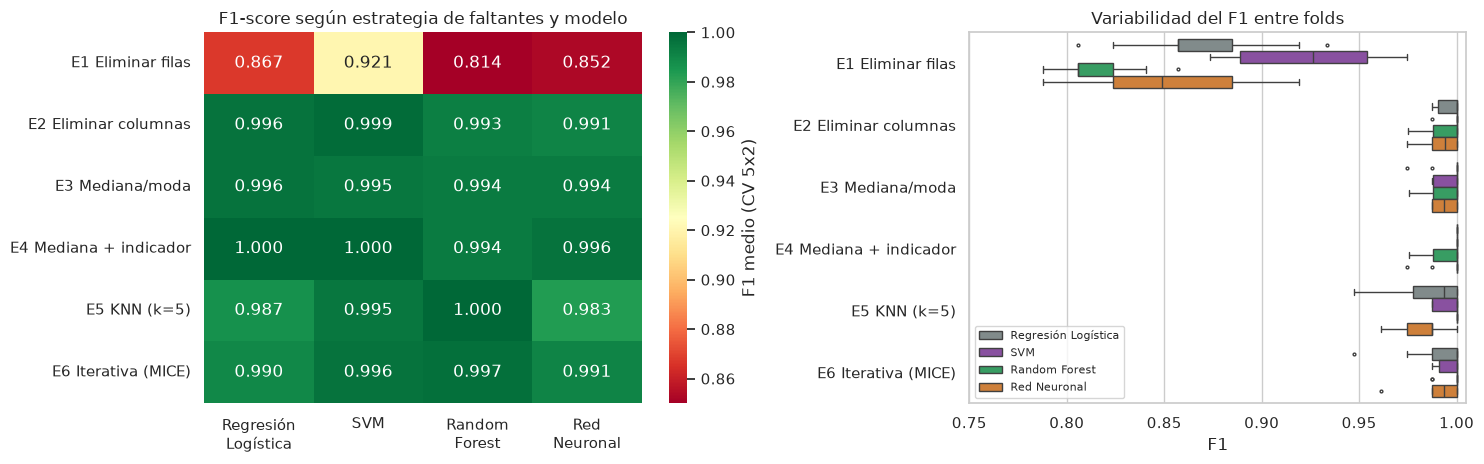

In [33]:
resumen_cv = cv_falt.groupby(["Estrategia", "Modelo"])[["F1", "Accuracy", "Recall", "AUC"]].agg(["mean", "std"])
f1_media = cv_falt.pivot_table(index="Estrategia", columns="Modelo", values="F1", aggfunc="mean")[list(modelos_finales)]
f1_desv = cv_falt.pivot_table(index="Estrategia", columns="Modelo", values="F1", aggfunc="std")[list(modelos_finales)]
recall_media = cv_falt.pivot_table(index="Estrategia", columns="Modelo", values="Recall", aggfunc="mean")[list(modelos_finales)]
tam = cv_falt.groupby("Estrategia")[["n_entrenamiento", "% ckd entrenamiento"]].mean().round(3)

print("F1-score medio en CV repetida (5x2) sobre Training")
display(f1_media.round(4))
print("Recall medio en CV repetida (5x2)")
display(recall_media.round(4))
print("Tamaño medio del conjunto de entrenamiento de cada fold y proporción de ckd")
display(tam)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
sns.heatmap(f1_media.rename(columns=lambda c: c.replace(" ", "\n", 1)), annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.85, vmax=1.0, ax=axes[0],
            cbar_kws={"label": "F1 medio (CV 5x2)"})
axes[0].set_title("F1-score según estrategia de faltantes y modelo"); axes[0].set_xlabel(""); axes[0].set_ylabel("")
sns.boxplot(data=cv_falt, y="Estrategia", x="F1", hue="Modelo", ax=axes[1], fliersize=2,
            order=list(ESTRATEGIAS), palette=["#7F8C8D", "#8E44AD", "#27AE60", "#E67E22"])
axes[1].set_title("Variabilidad del F1 entre folds"); axes[1].set_ylabel(""); axes[1].set_xlim(0.75, 1.005)
axes[1].legend(fontsize=8, loc="lower left")
plt.tight_layout(); guardar(fig, "13_faltantes_cv"); plt.show()

### 9.2 Confirmación sobre Test

Cada combinación estrategia × modelo se re-entrena con todo Training y se evalúa sobre Test. En E1 se reporta además el desempeño **solo sobre los pacientes completos de Test**, que es lo que una evaluación ingenua con eliminación de filas mediría.

In [34]:
filas = []
completos_test = X_test.notna().all(axis=1)
for nombre_modelo in modelos_finales:
    for etiqueta, estrategia in ESTRATEGIAS.items():
        pipe = pipeline_con_estrategia(nombre_modelo, estrategia)
        pipe, n_fit, _ = ajustar_con_estrategia(pipe, estrategia, X_train, y_train)
        m = evaluar(pipe, X_test, y_test)
        fila = {"Modelo": nombre_modelo, "Estrategia": etiqueta, "n_train": n_fit, **m}
        if estrategia == "eliminar_filas":
            fila["F1 solo Test completos"] = f1_score(y_test[completos_test], pipe.predict(X_test[completos_test]))
            fila["Acc solo Test completos"] = accuracy_score(y_test[completos_test], pipe.predict(X_test[completos_test]))
        filas.append(fila)
test_falt = pd.DataFrame(filas)
print(f"Pacientes completos en Test: {completos_test.sum()} de {len(X_test)} "
      f"(ckd: {y_test[completos_test].sum()})")
display(test_falt.pivot_table(index="Estrategia", columns="Modelo", values="F1")[list(modelos_finales)].round(4))
display(test_falt.pivot_table(index="Estrategia", columns="Modelo", values="Accuracy")[list(modelos_finales)].round(4))
display(test_falt[test_falt["Estrategia"] == "E1 Eliminar filas"]
        [["Modelo", "n_train", "F1", "Accuracy", "Recall", "F1 solo Test completos", "Acc solo Test completos"]].round(4))

Pacientes completos en Test: 37 de 80 (ckd: 11)


Modelo,Regresión Logística,SVM,Random Forest,Red Neuronal
Estrategia,,,,
E1 Eliminar filas,0.9011,0.9583,0.8235,0.8636
E2 Eliminar columnas,0.9691,1.0000,1.0000,0.9691
E3 Mediana/moda,0.9796,0.9899,1.0000,0.9691
E4 Mediana + indicador,0.9691,1.0000,1.0000,0.9691
E5 KNN (k=5),0.9899,0.9899,0.9899,0.9796
E6 Iterativa (MICE),0.9691,0.9899,0.9899,0.9691


Modelo,Regresión Logística,SVM,Random Forest,Red Neuronal
Estrategia,,,,
E1 Eliminar filas,0.8875,0.9500,0.8125,0.8500
E2 Eliminar columnas,0.9625,1.0000,1.0000,0.9625
E3 Mediana/moda,0.9750,0.9875,1.0000,0.9625
E4 Mediana + indicador,0.9625,1.0000,1.0000,0.9625
E5 KNN (k=5),0.9875,0.9875,0.9875,0.9750
E6 Iterativa (MICE),0.9625,0.9875,0.9875,0.9625


,Modelo,n_train,F1,Accuracy,Recall,F1 solo Test completos,Acc solo Test completos
0,Regresión Logística,121,0.9011,0.8875,0.82,1.0000,1.000
6,SVM,121,0.9583,0.9500,0.92,1.0000,1.000
12,Random Forest,121,0.8235,0.8125,0.70,0.9524,0.973
18,Red Neuronal,121,0.8636,0.8500,0.76,1.0000,1.000


### 9.3 ¿Es informativa la ausencia de datos?

Como el EDA mostró que los faltantes se concentran en los pacientes con ERC, se entrena una Regresión Logística que **solo conoce qué variables faltan** (24 indicadores 0/1, sin ningún valor clínico). Si este modelo predice bien la clase, la ausencia de datos es una señal por sí misma (fuga de información del proceso de registro), lo que tiene implicancias para la estrategia E4 y para la validez externa.

In [35]:
X_ind_train = X_train.isna().astype(int); X_ind_test = X_test.isna().astype(int)
lr_ind = LogisticRegression(max_iter=5000, random_state=SEED)
cv_ind = pd.DataFrame({m: [] for m in ["F1", "Accuracy", "AUC"]})
from sklearn.model_selection import cross_validate
r = cross_validate(lr_ind, X_ind_train, y_train, cv=CV_REP, scoring=["f1", "accuracy", "roc_auc"])
lr_ind.fit(X_ind_train, y_train)
p = lr_ind.predict_proba(X_ind_test)[:, 1]
print(f"Solo indicadores de faltante -> CV: F1 = {r['test_f1'].mean():.3f}, "
      f"Accuracy = {r['test_accuracy'].mean():.3f}, AUC = {r['test_roc_auc'].mean():.3f}")
print(f"                              Test: F1 = {f1_score(y_test, p >= 0.5):.3f}, "
      f"Accuracy = {accuracy_score(y_test, p >= 0.5):.3f}, AUC = {roc_auc_score(y_test, p):.3f}")
print(f"Referencia (predecir siempre ckd): Accuracy = {y_test.mean():.3f}")

Solo indicadores de faltante -> CV: F1 = 0.845, Accuracy = 0.817, AUC = 0.864
                              Test: F1 = 0.800, Accuracy = 0.775, AUC = 0.818
Referencia (predecir siempre ckd): Accuracy = 0.625


### 9.4 Respuesta a la pregunta particular

**Resultados principales del experimento (CV 5×2 sobre Training; F1 de la clase `ckd`):**

| Estrategia | Efecto observado |
|---|---|
| **E1 Eliminar filas** | **Es claramente la peor en los cuatro modelos**: el F1 cae de ≈0,99–1,00 a **0,81–0,92**, y el Recall a **0,69–0,86**; es decir, entre el 14 % y el 31 % de los enfermos quedan sin detectar. En Test el patrón se repite (Accuracy 0,81–0,95 frente a 0,96–1,00 con imputación). |
| **E2 Eliminar columnas (> 20 %)** | Prácticamente sin pérdida (F1 0,99–1,00): las columnas eliminadas (`rbc`, `rbcc`, `wbcc`, `pot`, `sod`) son redundantes con otras que se conservan (p. ej. `hemo`/`pcv` cubren la información de `rbcc`). |
| **E3 Mediana/moda** | Desempeño muy alto (F1 ≈ 0,99–1,00) con la estrategia más simple. |
| **E4 Mediana + indicador** | La mejor para los modelos lineales (LR y SVM llegan a F1 = 1,000 en CV). Parte de la mejora viene de que **la ausencia de un dato es informativa** (ver 9.3). |
| **E5 KNN / E6 Iterativa** | Similares a la mediana; KNN favorece al Random Forest (F1 = 1,000) pero empeora levemente a la Regresión Logística y a la red neuronal. Imputar con métodos multivariados **no aporta una mejora clara** frente a la mediana en este dataset. |

**¿Por qué eliminar filas es tan perjudicial?**
1. **Pérdida de datos:** cada modelo se entrena con ~97 pacientes en lugar de 256 (−62 %).
2. **Sesgo de selección:** como los faltantes se concentran en los enfermos (datos **no MCAR**), las filas completas son sobre todo `notckd`: la proporción de `ckd` en el entrenamiento cae de **62,5 % a 26,5 %**. Los modelos aprenden un "paciente típico con ERC" que es precisamente el menos típico (el que tiene todos los análisis), y además quedan sesgados hacia predecir `notckd` → **baja el Recall**, que es la métrica más crítica en este problema.
3. **Evaluación engañosa:** si también se evalúa solo sobre pacientes completos de Test (37 de 80, con apenas 11 `ckd`), la Regresión Logística, la SVM y la red neuronal entrenadas con E1 obtienen **Accuracy = 1,000**, mientras que sobre el Test real obtienen 0,89, 0,95 y 0,85. Descartar filas incompletas no solo empeora el modelo: **oculta el problema** si se aplica también en la evaluación.

**¿Es informativa la ausencia de datos? (9.3)** Sí: un modelo que solo sabe *qué variables faltan*, sin ningún valor clínico, alcanza AUC ≈ 0,86 en CV y 0,82 en Test (Accuracy 0,78 frente al 0,625 de predecir siempre `ckd`). Esto explica la leve mejora de E4, pero también es una **advertencia**: parte de esa señal refleja cómo se registraron los datos en este hospital y no la fisiología del paciente. En otro centro, con otro protocolo de laboratorio, esa señal podría no existir o invertirse. Por eso **se mantiene E3 (mediana) como estrategia principal**: su desempeño es prácticamente igual y es más prudente para generalizar.

**Respuesta.** En este dataset, **el tratamiento de los valores faltantes es la decisión de preprocesamiento con mayor impacto en el desempeño final**, más que la elección del modelo o de sus hiperparámetros. La diferencia entre *descartar* e *imputar* es de hasta ~18 puntos de F1 y ~30 puntos de Recall. En cambio, las distintas formas de imputar (mediana, KNN, MICE, con o sin indicadores) quedan todas dentro de ~1 punto de F1, una diferencia comparable a la variabilidad entre *folds*, porque las clases son muy separables y las variables más discriminantes (`hemo`, `sg`, `al`, `sc`, `htn`, `dm`) tienen pocos faltantes. La conclusión práctica es **conservar a todos los pacientes e imputar dentro del pipeline** (ajustando la imputación solo con datos de entrenamiento); la sofisticación del método de imputación es secundaria.

## 10. Discusión de resultados (§12)

**¿Qué significan los resultados obtenidos?**

1. **El problema es casi separable con los análisis de rutina.** Los cuatro modelos alcanzan F1 ≥ 0,99 en validación cruzada y Accuracy entre 0,96 y 1,00 en Test. Esto coincide con el EDA: hemoglobina, gravedad específica, albúmina, creatinina, hipertensión y diabetes separan casi perfectamente a los dos grupos, y todos los signos clínicos (`htn`, `dm`, `pe`, `ane`, etc.) aparecen únicamente en pacientes con ERC. También coincide con la literatura sobre este dataset: Qin *et al.* [4] reportan 99,75 % de Accuracy con Random Forest tras imputar con KNN, y Polat *et al.* [5] 98,5 % con SVM. Nuestros resultados están en ese rango, **usando un protocolo más estricto** (Test apartado desde el inicio y todo el preprocesamiento dentro del pipeline).

2. **Precision perfecta; los errores son siempre falsos negativos.** En Test ningún modelo produjo falsos positivos (Precision y Especificidad = 1,00). Todos los errores son pacientes con ERC clasificados como sanos (LR: 2, SVM: 1, Red Neuronal: 3, RF: 0), y en total son solo 3 pacientes distintos (8.3). Dos de ellos tienen valores **similares a los de un paciente sano** (hemoglobina 13,9 y 16,1 g/dl, hematocrito 52 %, sin hipertensión ni diabetes): son probablemente casos en **estadio temprano**, que el propio dataset busca representar ("*early stage*"). Son los más difíciles y, a la vez, los más importantes de detectar. El tercero es el caso opuesto (ver el punto 5).

3. **El Random Forest fue el modelo más adecuado para este problema.** Es el único con Recall = 1,00 en Test y también tiene el mayor Recall en CV (1,00). Al promediar árboles que dividen por umbrales, es robusto a los outliers de `sc`/`bu` y a las variables colineales, y en los casos límite asigna probabilidades de ERC más altas que los demás modelos (p. ej. 0,72 y 0,95 donde la LR da 0,39 y 0,24). Sin embargo, **con 80 pacientes en Test la diferencia entre modelos es de 1 a 3 pacientes**, del mismo orden que la variabilidad entre *folds* de CV (desvío ≈ 0,005–0,006 de F1): no puede afirmarse que un modelo sea estadísticamente superior. La lectura correcta es que **los cuatro modelos resuelven el problema** y que el RF es el que mejor protege contra el error más costoso.

4. **Modelos lineales vs. no lineales.** La Regresión Logística (F1 Test 0,980) queda muy cerca de los modelos más complejos, lo que confirma que la frontera es casi lineal. La SVM eligió kernel RBF con `C = 10`, pero la versión lineal logró F1 CV = 0,995 (frente a 0,9975): **la no linealidad aporta muy poco**.

5. **Red neuronal.** Con una arquitectura pequeña (24 → 8 → 1 con dropout 0,3, elegida por la búsqueda y empatada en CV con 24 → 16 → 8 → 1 sin dropout) alcanza prácticamente la misma F1 en CV que los demás modelos (0,995), pero en Test es la que más falsos negativos comete (3). Su AUC en Test sigue siendo alta (0,995), así que **ordena bien a casi todos los pacientes, pero con umbral 0,5 los casos límite quedan por debajo del corte**. Un error es especialmente instructivo: el paciente 61 tiene **creatinina 32 mg/dl y urea 391 mg/dl** (valores extremos, inequívocamente de ERC) y hemoglobina y hematocrito faltantes, pero la red le asigna P(ckd) ≈ 0,00. Estandarizados, esos valores quedan muy fuera del rango visto en el entrenamiento, y una red ReLU **extrapola de forma impredecible** fuera de ese rango. El Random Forest, que solo compara contra umbrales, es inmune a este problema (P = 0,90). Con solo ~256 pacientes, una red neuronal no tiene ventaja sobre modelos clásicos y es más sensible a la inicialización, a la parada temprana y a los outliers; una transformación logarítmica de `sc`, `bu` y `bgr` probablemente la mejoraría. Además, la primera versión (tasa de aprendizaje 0,001) llegaba al límite de épocas sin converger (mejor época 191 de 200); con 0,003 el *early stopping* actúa (mejor época 134 de 154).

6. **Sobreajuste y generalización.** Los modelos llegan a F1 ≈ 1,00 en entrenamiento, pero la brecha con la CV es mínima (≤ 0,005) y el Test confirma la estimación de CV (diferencias de 0 a 4 puntos, explicadas por 1–3 pacientes). **No hay evidencia de sobreajuste relevante**; el F1 de entrenamiento de 1,00 refleja la separabilidad del problema más que memorización.

7. **Efecto de los hiperparámetros.** Dentro de cada grilla las diferencias entre las mejores configuraciones fueron pequeñas (menos de 1,5 puntos de F1 en CV; en la red neuronal, entre 0,985 y 0,995). La regularización muy fuerte (`C = 0,01` en la LR) es la que más empeora el desempeño, porque aplasta coeficientes de variables realmente informativas. `class_weight='balanced'` no mejoró: el desbalance es moderado y las clases están muy separadas.

8. **Efecto del preprocesamiento.** El paso más influyente fue el **tratamiento de faltantes** (Sección 9): descartar filas incompletas degrada todos los modelos de forma marcada, mientras que las distintas imputaciones son equivalentes. La estandarización es imprescindible para LR, SVM y la red (sin ella, variables como `wbcc`, del orden de miles, dominarían la distancia y la regularización).

9. **Variables más importantes.** Los coeficientes de la LR y la importancia por permutación del RF coinciden en destacar `hemo`, `sg`, `pcv`, `al`, `sc`, `htn`, `dm` y `rbcc`, todas con **sentido clínico** (anemia renal, capacidad de concentración de la orina, proteinuria, filtración glomerular y los dos principales factores de riesgo de ERC [2]). Que el modelo se apoye en variables clínicamente plausibles aumenta la confianza en él.

**Limitaciones y validez.** (i) Dataset pequeño (400 pacientes) de **un único hospital** de la India: los resultados probablemente sobreestiman el desempeño en otras poblaciones. (ii) Los faltantes están asociados a la clase, por lo que parte de la separabilidad puede deberse al proceso de registro. (iii) No hay información de estadio de ERC ni de la tasa de filtración glomerular estimada (eGFR), que es el criterio diagnóstico real [2]. (iv) El Test de 80 pacientes da estimaciones con alta varianza (cada error vale 1,25 puntos de Accuracy).

## 11. Conclusiones (§13)

- **Sobre el problema:** la ERC puede identificarse con muy alta precisión a partir de análisis de sangre y orina de rutina y antecedentes clínicos. Los marcadores decisivos (hemoglobina, gravedad específica, albúmina, creatinina, hipertensión y diabetes) coinciden con el conocimiento médico.
- **Sobre los modelos:** los cuatro modelos lograron F1 ≥ 0,99 en validación cruzada. En Test, el **Random Forest** fue el más adecuado (Accuracy, Precision, Recall, F1 y AUC = 1,00; ningún falso negativo), seguido por la SVM (1 FN), la Regresión Logística (2 FN) y la Red Neuronal (3 FN). Como las diferencias son de 1 a 3 pacientes, **la Regresión Logística es una alternativa perfectamente válida** si se prioriza la interpretabilidad.
- **Métricas:** en un problema de tamizaje médico el **Recall** es la métrica decisiva; la Accuracy sola no permite distinguir entre los modelos, porque todos superan el 96 %.
- **Preprocesamiento (pregunta particular):** el tratamiento de faltantes fue la decisión con mayor impacto. **Eliminar pacientes incompletos redujo el F1 hasta 18 puntos y el Recall hasta 31 puntos**, porque descarta al 60 % de la muestra y sesga la distribución de clases (los faltantes no son aleatorios). Cualquier imputación hecha dentro del pipeline (mediana, KNN, MICE) dio resultados equivalentes. Los indicadores de faltante mejoran levemente, pero explotan un artefacto del registro que puede no generalizar.
- **Hiperparámetros:** el ajuste con GridSearchCV produjo mejoras pequeñas (≤ 1–2 puntos de F1). Sí fue importante para la red neuronal, donde la tasa de aprendizaje determinó si el entrenamiento llegaba a converger. La red resultó además sensible a los valores extremos de creatinina y urea, que el Random Forest maneja sin problema.
- **Metodología:** separar Test al inicio y encapsular todo el preprocesamiento en `Pipeline` permitió obtener estimaciones honestas; la coincidencia entre CV y Test lo confirma.
- **Trabajo futuro:** (1) validar en un dataset externo de otro hospital; (2) validación cruzada anidada [14] y repeticiones con distintas semillas de partición para obtener intervalos de confianza; (3) ajustar el umbral de decisión (p. ej. priorizar Recall ≥ 0,99) y calibrar las probabilidades, y aplicar transformación logarítmica a `sc`, `bu` y `bgr` para la red neuronal; (4) probar Gradient Boosting (XGBoost/LightGBM), que manejan faltantes de forma nativa; (5) selección de variables para obtener un modelo con pocos análisis de bajo costo; (6) explicar predicciones individuales (p. ej. SHAP) para uso clínico.

## 12. Referencias bibliográficas (§14)

Formato IEEE.

[1] L. J. Rubini, P. Soundarapandian y P. Eswaran, "Chronic Kidney Disease," *UCI Machine Learning Repository*, 2015. [En línea]. Disponible: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease. DOI: 10.24432/C5G020.

[2] Kidney Disease: Improving Global Outcomes (KDIGO) CKD Work Group, "KDIGO 2012 clinical practice guideline for the evaluation and management of chronic kidney disease," *Kidney International Supplements*, vol. 3, no. 1, pp. 1–150, 2013.

[3] GBD Chronic Kidney Disease Collaboration, "Global, regional, and national burden of chronic kidney disease, 1990–2017: a systematic analysis for the Global Burden of Disease Study 2017," *The Lancet*, vol. 395, no. 10225, pp. 709–733, 2020.

[4] J. Qin, L. Chen, Y. Liu, C. Liu, C. Feng y B. Chen, "A machine learning methodology for diagnosing chronic kidney disease," *IEEE Access*, vol. 8, pp. 20991–21002, 2020.

[5] H. Polat, H. Danaei Mehr y A. Cetin, "Diagnosis of chronic kidney disease based on support vector machine by feature selection methods," *Journal of Medical Systems*, vol. 41, no. 4, art. 55, 2017.

[6] C. Cortes y V. Vapnik, "Support-vector networks," *Machine Learning*, vol. 20, no. 3, pp. 273–297, 1995.

[7] L. Breiman, "Random forests," *Machine Learning*, vol. 45, no. 1, pp. 5–32, 2001.

[8] F. Pedregosa *et al.*, "Scikit-learn: Machine learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[9] I. Goodfellow, Y. Bengio y A. Courville, *Deep Learning*. Cambridge, MA, EE. UU.: MIT Press, 2016.

[10] T. Hastie, R. Tibshirani y J. Friedman, *The Elements of Statistical Learning: Data Mining, Inference, and Prediction*, 2.ª ed. Nueva York, NY, EE. UU.: Springer, 2009.

[11] D. B. Rubin, "Inference and missing data," *Biometrika*, vol. 63, no. 3, pp. 581–592, 1976.

[12] S. van Buuren y K. Groothuis-Oudshoorn, "mice: Multivariate imputation by chained equations in R," *Journal of Statistical Software*, vol. 45, no. 3, pp. 1–67, 2011.

[13] O. Troyanskaya *et al.*, "Missing value estimation methods for DNA microarrays," *Bioinformatics*, vol. 17, no. 6, pp. 520–525, 2001.

[14] S. Varma y R. Simon, "Bias in error estimation when using cross-validation for model selection," *BMC Bioinformatics*, vol. 7, art. 91, 2006.

[15] D. R. Cox, "The regression analysis of binary sequences," *Journal of the Royal Statistical Society: Series B*, vol. 20, no. 2, pp. 215–242, 1958.

[16] D. P. Kingma y J. Ba, "Adam: A method for stochastic optimization," en *Proc. 3rd Int. Conf. Learning Representations (ICLR)*, San Diego, CA, EE. UU., 2015.

[17] N. Srivastava, G. Hinton, A. Krizhevsky, I. Sutskever y R. Salakhutdinov, "Dropout: A simple way to prevent neural networks from overfitting," *Journal of Machine Learning Research*, vol. 15, pp. 1929–1958, 2014.

[18] T. Fawcett, "An introduction to ROC analysis," *Pattern Recognition Letters*, vol. 27, no. 8, pp. 861–874, 2006.

In [36]:
# Registro de versiones para reproducibilidad
print("Semilla:", SEED)
print("Tamaños: train =", X_train.shape, "| test =", X_test.shape)
print("Figuras guardadas en:", FIG_DIR.resolve())

Semilla: 42
Tamaños: train = (320, 24) | test = (80, 24)
Figuras guardadas en: /home/user/jumbo-store/TP_ML_Enfermedad_Renal_Cronica/figuras
